# HospitalFlow: Predictive Healthcare Inventory Intelligence

## Project Overview

This notebook implements the machine-learning and data-science component of **HospitalFlow**, a predictive healthcare inventory intelligence system for hospitals and clinics.

### What is HospitalFlow?

HospitalFlow helps hospitals and clinics predict inventory shortages **before they happen**. Instead of reacting to stockouts after they occur, HospitalFlow gives procurement officers early warning so they can take preventive action.

The system analyzes:
- Historical inventory transactions and consumption patterns
- Current inventory levels and trends
- Supplier performance and lead times
- Hospital and department activity levels
- Patient admissions and disease information

And produces:
- **7-day, 14-day, and 30-day demand forecasts** for every product at every location
- **Stockout risk probabilities** with confidence levels
- **Recommended reorder quantities** based on demand forecasts and supplier lead times
- **Risk categorization** (LOW, MEDIUM, CRITICAL) to guide procurement priority

### The Healthcare Inventory Problem

Hospitals maintain large inventories of medical supplies, medications, and equipment. Managing these inventories presents a difficult balancing act:

**The Stockout Problem**: If hospitals don't keep enough stock, patients may not receive necessary care when they need it. A critical supply shortage can delay surgeries, compromise emergency response, or affect patient safety.

**The Overstocking Problem**: Keeping excessive inventory ties up capital, requires expensive storage space, increases waste from expired products, and complicates inventory management. In healthcare, many products have short shelf lives.

**The Unpredictability Problem**: Hospitals traditionally rely on manual monitoring and historical experience to decide when to reorder. But demand varies based on:
- Patient admissions (number and acuity)
- Disease outbreaks or seasonal patterns
- Department activity levels
- Supplier reliability
- Time of year or day of week

Without systematic forecasting, procurement teams often rely on gut feeling, which can result in either stockouts or excess inventory.

### Why This Matters

**For Hospital Operations**:
- Prevents treatment delays from missing supplies
- Reduces capital tied up in excess inventory
- Improves planning and procurement efficiency
- Enables faster response to demand changes

**For Patients**:
- Ensures necessary supplies are available when needed
- Supports timely, quality care

**For Healthcare Economics**:
- Reduces waste and unnecessary expenditure
- Improves operational efficiency
- Enables better resource allocation

### What This Notebook Does

This notebook is the "brain" of HospitalFlow. It:

1. **Loads and inspects** historical inventory and operational data
2. **Cleans and validates** data quality
3. **Engineers features** that capture consumption patterns, supplier performance, and patient activity
4. **Tests a hypothesis**: Does patient admission and disease information improve demand forecasting?
5. **Trains two predictive models**:
   - A **demand forecasting model** to predict future product consumption
   - A **stockout risk model** to predict which products are likely to run out
6. **Evaluates model performance** on held-out test data
7. **Creates a final prediction table** that feeds into the HospitalFlow application
8. **Saves trained models** for production use

### Key Questions This Notebook Answers

1. **How much of each product will be consumed over the next 7 days?**
2. **Which products are likely to stock out in the next 7 days?**
3. **When could a product run out (days of stock remaining)?**
4. **How much should be reordered?**
5. **Does patient admission and disease activity help predict inventory demand?**
6. **How reliable are these predictions?**

### Important: HospitalFlow is a Decision-Support System

HospitalFlow does NOT automatically purchase products. Instead, it **empowers procurement officers** with better information. The procurement team reviews HospitalFlow's recommendations and makes the final purchasing decisions based on business judgment, budget, and other operational factors.

This notebook demonstrates how data science creates practical business value in healthcare operations.

# SECTION 2: BUSINESS UNDERSTANDING

## The Problem Statement

Hospitals need to maintain enough medical supplies to serve patients without holding unnecessarily large amounts of inventory. Traditional inventory management often depends on:
- Manual monitoring by procurement staff
- Historical experience and intuition
- Periodic ordering based on arbitrary reorder points
- Reactive responses to stockouts after they occur

This manual approach creates **two persistent problems**:

### Problem 1: Stockouts

When a product runs out unexpectedly:
- Surgical procedures may be delayed or rescheduled
- Emergency treatments may be compromised
- Patients receive different care than planned
- Staff must scramble to find alternatives
- Quality of care and patient safety may be affected
- Hospital reputation and patient satisfaction suffer

Example: If a hospital runs out of a critical antibiotic during an infectious disease outbreak, patient treatment is delayed while the hospital sources emergency supply.

### Problem 2: Overstocking

When hospitals maintain too much inventory:
- Capital is tied up that could be invested elsewhere
- Expensive storage space is required
- Products expire or degrade before use
- Inventory management becomes administratively burdensome
- Waste increases
- Supplier obsolescence risk increases

Example: A hospital orders 1 year's worth of a product to get a bulk discount, but the formulation changes mid-year and most of it becomes unusable.

## The Business Objective

**HospitalFlow's Mission**: *Predict future inventory demand and stockout risk early enough for hospital procurement teams to take action.*

By forecasting demand accurately and identifying stockout risk, procurement officers can:
- Order supplies **before** they run out
- Avoid emergency ordering at premium prices
- Order the right quantities to minimize both waste and shortages
- Plan procurement more efficiently
- Reduce capital tied up in excess inventory

## Key Business Questions HospitalFlow Answers

### 1. Consumption Analysis
- **What products are being consumed fastest?** Identify high-velocity items needing more attention.
- **Which departments drive the most consumption?** Allocate resources appropriately.
- **How does consumption vary over time?** Identify patterns and anomalies.

### 2. Demand Forecasting
- **What is the expected demand for each product over the next 7 days?** Plan procurement accordingly.
- **How certain are we about these forecasts?** Understand confidence and uncertainty.

### 3. Inventory Risk Assessment
- **Which products are likely to run out?** Prioritize procurement attention.
- **When could they run out?** Understand urgency and lead time requirements.
- **How much buffer stock is needed?** Calculate safety stock requirements.

### 4. Operational Dependencies
- **Does patient admission activity affect demand?** Should we monitor hospital census?
- **Does disease prevalence affect demand?** Should we track epidemiological data?
- **Do specific disease outbreaks drive certain product consumption?** Can we predict based on disease information?

### 5. Supplier Considerations
- **How do supplier lead times impact inventory risk?** Plan orders based on supplier reliability.
- **Which suppliers are most critical to managing inventory?** Focus vendor management efforts.

### 6. Procurement Planning
- **How much should be reordered?** Calculate optimal order quantities.
- **What is the procurement urgency?** Identify low vs critical priority items.
- **Can we reduce total inventory while improving service?** Optimize the inventory-service tradeoff.

## Defining Success

From the hospital's perspective, HospitalFlow is successful when:

✓ **Service Improves**: Stockouts decrease, all patients receive planned care
✓ **Efficiency Improves**: Procurement teams spend less time on manual monitoring
✓ **Capital Improves**: Total inventory value decreases while service improves
✓ **Confidence Improves**: Procurement officers trust the forecasts and use them for decisions
✓ **Adoption Improves**: Staff use HospitalFlow as part of their daily workflow

## Why Machine Learning Matters

Simple historical averages cannot capture:
- **Seasonality**: Demand varies by time of year
- **Trends**: Consumption patterns change over time
- **Dependencies**: Patient activity affects product demand
- **Interactions**: Multiple factors work together
- **Nonlinear relationships**: Relationships aren't always proportional

Machine learning can discover these complex patterns automatically from data, enabling more accurate forecasts than manual approaches.

## The Data Science Workflow

To answer these business questions, we follow a systematic data science process:

1. **Understand the business** (this section)
2. **Understand the data** (where it comes from, what it represents)
3. **Load and inspect** the data
4. **Check data quality** and fix problems
5. **Explore the data** visually and statistically
6. **Engineer features** that encode domain knowledge
7. **Create prediction targets** (what we're trying to predict)
8. **Prevent data leakage** (use only information available at prediction time)
9. **Split data chronologically** (train on past, test on future)
10. **Build and train models** to make predictions
11. **Evaluate performance** on held-out test data
12. **Interpret results** and explain to stakeholders
13. **Save models** for production use
14. **Monitor performance** over time

This notebook implements this complete workflow.

# SECTION 3: DATA UNDERSTANDING

## Where Does the Data Come From?

In a production HospitalFlow system, data comes from hospital operational systems:
- **Inventory Management System**: Tracks product stock levels, receipts, and consumption
- **Hospital Information System (HIS)**: Records patient admissions, discharges, and department assignments
- **Pharmacy System**: Tracks medication dispensing and usage
- **Laboratory System**: Records test orders and supplies used
- **Supplier Systems**: Integration for lead times, delivery history, pricing
- **Disease Surveillance**: Admission diagnoses, disease codes, epidemiological data

For this notebook, we use an **integrated dataset** that combines all this information into a single table for analysis.

## What Each Dataset Represents

The integrated dataset contains one row per inventory transaction or measurement. Let's understand the major components:

### Inventory Data
- **date**: The date of the transaction or measurement
- **facility_id, facility_name**: Which hospital or clinic
- **product_id, product_name**: Which item (drug, supply, equipment, etc.)
- **category, unit**: Product classification and unit of measurement
- **opening_stock**: Stock at the beginning of the day
- **closing_stock**: Stock at the end of the day
- **quantity_used**: Amount consumed that day
- **quantity_received**: Amount purchased/delivered that day

### Product/Supplier Data
- **supplier**: Which company supplied this product
- **supplier_lead_time_days**: How many days it takes to receive an order
- **unit_cost**: Price per unit

### Department Data
- **department**: Which department (surgery, ICU, emergency, pharmacy, etc.)
- **facility_rolling_7d_usage**: Average daily consumption over past 7 days
- **facility_rolling_14d_usage, facility_rolling_30d_usage**: Average over longer periods
- **department_rolling_7d_usage, department_rolling_14d_usage**: Department-specific consumption patterns

### Patient Activity Data
- **hospital_admissions**: Total patients admitted that day
- **hospital_emergency_admissions**: Emergency department admissions
- **hospital_elective_admissions**: Planned admissions
- **department_admissions**: Admissions to this specific department

### Disease Information Data
- **dominant_disease_category, dominant_disease_name**: Primary disease for this product's department
- **disease_cat_infectious_admissions**: Admissions with infectious diseases
- **disease_cat_respiratory_admissions**: Respiratory conditions
- **disease_cat_pediatric_admissions**: Pediatric cases
- (and similar for other disease categories)
- **unique_diseases_observed**: Count of different diseases seen that day

### Derived Metrics
- **facility_stockout_risk**: Whether product was in danger of stocking out
- **stockout_flag**: Whether the product actually ran out
- **facility_days_of_stock**: Estimated days of remaining stock
- **facility_forecast_7d_baseline**: Simple moving average forecast

## Understanding "One Row"

**Important**: One row represents **the inventory state and activity for one product at one facility/department on one date**.

For example, one row might represent:
- Date: 2025-01-15
- Facility: City General Hospital
- Department: Intensive Care Unit
- Product: Nitrile Gloves (box of 100 count)
- Supplier: MedSupply Corp
- Opening Stock: 5,000 units
- Quantity Received: 2,000 units
- Quantity Used: 1,200 units
- Closing Stock: 5,800 units
- Hospital Admissions That Day: 45
- Infectious Disease Admissions: 8
- Days of Stock: 4.8 days
- Forecast (7-day demand): 8,400 units

If we have 30 products, 5 departments, 3 facilities, and 365 days of data, we'd have approximately **164,250 rows** (though there may be gaps).

This structure allows us to:
- Track every product's consumption separately
- See how patient activity affects different departments
- Understand supplier performance per product
- Compare products across facilities
- Build department-specific or facility-specific models if needed

# SECTION 4: LOAD THE DATA

## Why We Load the Dataset

Before we can answer any business questions or build any models, we need to load the data into our analysis environment.

Loading the data allows us to:
- Inspect what we're working with
- Understand data structure and size
- Check for obvious problems
- Begin exploring patterns

**pandas** is a Python library specifically designed for working with tabular data (data organized in rows and columns). It makes it easy to load CSV files, manipulate data, and prepare it for analysis.

**What will happen in this section:**
1. We'll import all necessary Python libraries
2. We'll locate the data file
3. We'll load it into a pandas DataFrame
4. We'll examine the first and last few rows
5. We'll check basic information like the number of rows and columns

A **DataFrame** is like a spreadsheet in Python—it has rows and columns, and we can perform calculations, filter, sort, and transform the data within it.

In [45]:
# ============================================================
# SECTION 4: LOAD THE DATA - IMPORTS AND CONFIGURATION
# ============================================================
#
# Import all necessary libraries for data analysis, visualization,
# and machine learning.
#
# Libraries Used:
# - pandas: Data manipulation and analysis
# - numpy: Numerical computations
# - matplotlib/seaborn: Data visualization
# - scikit-learn: Machine learning models and preprocessing
# - joblib: Saving and loading trained models
# ============================================================

import json
import os
from datetime import date
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# ============================================================
# CONFIGURE PANDAS AND VISUALIZATION DISPLAY
# ============================================================
#
# These settings make it easier to see the full data when
# we display DataFrames and plots in the notebook.
# ============================================================

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

# ============================================================
# RANDOM STATE AND CONFIGURATION CONSTANTS
# ============================================================
#
# RANDOM_STATE ensures reproducibility. When we set this,
# we get the same random results every time we run the notebook.
#
# RISK_THRESHOLDS categorize stockout probabilities into
# business-friendly categories (LOW, MEDIUM, CRITICAL).
# These thresholds can be adjusted based on hospital policy.
# ============================================================

RANDOM_STATE = 42
RISK_THRESHOLDS = {
    "low": 0.30,      # Probability <= 30%: LOW risk
    "medium": 0.70,   # Probability 30-70%: MEDIUM risk
                      # Probability > 70%: CRITICAL risk
}

# ============================================================
# LOCATE THE DATA FILE
# ============================================================
#
# This code searches for the dataset in multiple possible
# locations. We check:
# 1. data/ subdirectory
# 2. root of project
# 3. alternate filename variations
#
# This makes the notebook more robust to different directory
# structures and prevents errors from missing files.
# ============================================================

NOTEBOOK_DIR = Path(".").resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR / "data").exists() else Path(".").resolve()

DATA_CANDIDATES = [
    PROJECT_ROOT / "data" / "hospitalflow_integrated_inventory_disease_dataset_2025.csv",
    PROJECT_ROOT / "hospitalflow_integrated_inventory_disease_dataset_2025.csv",
    PROJECT_ROOT / "hospitalflow_integrated_inventory_disease_dataset_2025(1).csv",
]

# Find the first data file that exists
data_path = next((p for p in DATA_CANDIDATES if p.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Could not find hospitalflow_integrated_inventory_disease_dataset_2025.csv. "
        "Please check that the data file is in the correct location."
    )

print(f"Using data file: {data_path}")

Using data file: C:\Users\Admin\OneDrive\Desktop\test\notebooks\hospitalflow_integrated_inventory_disease_dataset_2025.csv


In [46]:
# ============================================================
# LOAD THE DATA
# ============================================================
#
# Read the CSV file into a pandas DataFrame.
# A DataFrame is a table-like structure with rows and columns.
#
# We also convert the "date" column to datetime format so
# Python understands it as a date, not just text.
# ============================================================

df = pd.read_csv(data_path)

# Convert the date column to datetime format
# errors='coerce' means invalid dates become NaT (Not a Time)
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# ============================================================
# INITIAL DATA EXAMINATION
# ============================================================
#
# Before doing any analysis, we look at a small sample of
# the data to verify it loaded correctly and understand
# its structure.
# ============================================================

print("="*60)
print("DATASET BASIC INFORMATION")
print("="*60)
print(f"Total rows: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print()

print("First 5 rows of data:")
display(df.head())

print("\nLast 5 rows of data:")
display(df.tail())

print("\nData types and missing values:")
display(df.info())

DATASET BASIC INFORMATION
Total rows: 17,700
Total columns: 67
Date range: 2025-01-01 00:00:00 to 2025-08-24 00:00:00

First 5 rows of data:


,date,facility_id,facility_name,department,product_id,product_name,category,unit,supplier,opening_stock,quantity_received,quantity_used,closing_stock,unit_cost_kes,supplier_lead_time_days,stockout_flag,day_of_week,month,is_weekend,zip_department_match,disease_department_match,department_admissions,department_emergency_admissions,department_unique_diseases,dominant_disease_id,dominant_disease_name,dominant_disease_category,dominant_disease_admissions,hospital_admissions,hospital_emergency_admissions,hospital_elective_admissions,unique_diseases_observed,disease_cat_cardiac_admissions,disease_cat_endocrine_admissions,disease_cat_hematological_admissions,disease_cat_infectious_admissions,disease_cat_neurological_admissions,disease_cat_orthopedic_admissions,disease_cat_pediatric_admissions,disease_cat_renal_admissions,disease_cat_respiratory_admissions,disease_cat_surgical_admissions,disease_cat_trauma_admissions,hospital_admissions_7d_avg,hospital_emergency_admissions_7d_avg,department_admissions_7d_avg,hospital_admissions_7d_change_pct,department_admissions_7d_change_pct,facility_stock_value_kes,facility_lag_1d_usage,facility_lag_7d_usage,facility_rolling_7d_usage,facility_rolling_14d_usage,facility_rolling_30d_usage,facility_usage_std_14d,facility_forecast_7d_baseline,facility_reorder_point_units,facility_days_of_stock,facility_stockout_risk,department_lag_1d_usage,department_lag_7d_usage,department_rolling_7d_usage,department_rolling_14d_usage,department_rolling_30d_usage,department_usage_std_14d,department_usage_share_of_product,department_usage_change_pct
0,2025-01-01,FAC001,Hospital A,Emergency,MED001,Nitrile Gloves,PPE,Box (100),MedSupply Kenya,1303,0,55,1248,850,7,0,Wednesday,1,0,Emergency,True,4.0,2.0,4.0,4.0,Sepsis,Infectious,1.0,26,13,13,16,1,0,1,8,1,1,3,2,3,2,4,NaN,NaN,NaN,NaN,NaN,953700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN,NaN,NaN,NaN,0.192,NaN
1,2025-01-01,FAC001,Hospital A,Emergency,MED002,5ml Syringes,Injection Supplies,Box (100),AfyaMed Distributors,477,0,20,457,620,11,0,Wednesday,1,0,Emergency,True,4.0,2.0,4.0,4.0,Sepsis,Infectious,1.0,26,13,13,16,1,0,1,8,1,1,3,2,3,2,4,26.0,13.0,4.0,0.0,0.0,259160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN,NaN,NaN,NaN,0.188,NaN
2,2025-01-01,FAC001,Hospital A,Emergency,MED003,10ml Syringes,Injection Supplies,Box (100),AfyaMed Distributors,352,0,12,340,780,11,0,Wednesday,1,0,Emergency,True,4.0,2.0,4.0,4.0,Sepsis,Infectious,1.0,26,13,13,16,1,0,1,8,1,1,3,2,3,2,4,26.0,13.0,4.0,0.0,0.0,243360,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN
3,2025-01-01,FAC001,Hospital A,Emergency,MED004,IV Cannulas 20G,IV Supplies,Box (50),MedSupply Kenya,239,0,10,229,1450,14,0,Wednesday,1,0,Emergency,True,4.0,2.0,4.0,4.0,Sepsis,Infectious,1.0,26,13,13,16,1,0,1,8,1,1,3,2,3,2,4,26.0,13.0,4.0,0.0,0.0,303050,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN
4,2025-01-01,FAC001,Hospital A,Emergency,MED005,IV Giving Sets,IV Supplies,Box (20),HealthLink Supplies,157,0,9,148,1680,12,0,Wednesday,1,0,Emergency,True,4.0,2.0,4.0,4.0,Sepsis,Infectious,1.0,26,13,13,16,1,0,1,8,1,1,3,2,3,2,4,26.0,13.0,4.0,0.0,0.0,213360,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN



Last 5 rows of data:


,date,facility_id,facility_name,department,product_id,product_name,category,unit,supplier,opening_stock,quantity_received,quantity_used,closing_stock,unit_cost_kes,supplier_lead_time_days,stockout_flag,day_of_week,month,is_weekend,zip_department_match,disease_department_match,department_admissions,department_emergency_admissions,department_unique_diseases,dominant_disease_id,dominant_disease_name,dominant_disease_category,dominant_disease_admissions,hospital_admissions,hospital_emergency_admissions,hospital_elective_admissions,unique_diseases_observed,disease_cat_cardiac_admissions,disease_cat_endocrine_admissions,disease_cat_hematological_admissions,disease_cat_infectious_admissions,disease_cat_neurological_admissions,disease_cat_orthopedic_admissions,disease_cat_pediatric_admissions,disease_cat_renal_admissions,disease_cat_respiratory_admissions,disease_cat_surgical_admissions,disease_cat_trauma_admissions,hospital_admissions_7d_avg,hospital_emergency_admissions_7d_avg,department_admissions_7d_avg,hospital_admissions_7d_change_pct,department_admissions_7d_change_pct,facility_stock_value_kes,facility_lag_1d_usage,facility_lag_7d_usage,facility_rolling_7d_usage,facility_rolling_14d_usage,facility_rolling_30d_usage,facility_usage_std_14d,facility_forecast_7d_baseline,facility_reorder_point_units,facility_days_of_stock,facility_stockout_risk,department_lag_1d_usage,department_lag_7d_usage,department_rolling_7d_usage,department_rolling_14d_usage,department_rolling_30d_usage,department_usage_std_14d,department_usage_share_of_product,department_usage_change_pct
17695,2025-08-24,FAC001,Hospital A,Theatre,MED011,Pregnancy Test Kits,Diagnostics,Box (50),HealthLink Supplies,0,0,0,0,1800,11,1,Sunday,8,1,Surgery,True,2.0,1.0,2.0,11.0,Fracture Femur,Orthopedic,1.0,18,7,11,12,2,0,0,4,1,5,0,1,1,3,1,18.0,7.0,2.0,0.0,0.000,0,0.0,17.0,3.286,5.714,6.333,8.660,23.0,65.7,0.0,Critical,0.0,6.0,0.857,1.500,1.467,2.594,0.355,-100.000
17696,2025-08-24,FAC001,Hospital A,Theatre,MED012,IV Extension Sets,IV Supplies,Box (25),MedSupply Kenya,0,0,0,0,1350,11,1,Sunday,8,1,Surgery,True,2.0,1.0,2.0,11.0,Fracture Femur,Orthopedic,1.0,18,7,11,12,2,0,0,4,1,5,0,1,1,3,1,18.0,7.0,2.0,0.0,0.000,0,0.0,0.0,0.000,7.857,8.500,11.326,0.0,0.0,NaN,Low,0.0,0.0,0.000,1.857,2.067,3.348,0.000,NaN
17697,2025-08-24,FAC001,Hospital A,Theatre,MED013,Examination Gloves,PPE,Box (100),MedSupply Kenya,639,0,27,612,690,9,0,Sunday,8,1,Surgery,True,2.0,1.0,2.0,11.0,Fracture Femur,Orthopedic,1.0,18,7,11,12,2,0,0,4,1,5,0,1,1,3,1,18.0,7.0,2.0,0.0,0.000,400200,122.0,120.0,59.857,56.214,64.900,61.496,419.0,897.9,9.7,High,23.0,22.0,9.857,10.571,13.033,12.786,0.000,173.913
17698,2025-08-24,FAC001,Hospital A,Theatre,MED014,Cotton Wool,Wound Care,Pack (500g),HealthLink Supplies,0,0,0,0,320,8,1,Sunday,8,1,Surgery,True,2.0,1.0,2.0,11.0,Fracture Femur,Orthopedic,1.0,18,7,11,12,2,0,0,4,1,5,0,1,1,3,1,12.0,4.0,12.0,50.0,-83.333,0,0.0,51.0,33.571,25.786,26.200,23.182,235.0,503.6,0.0,Critical,0.0,7.0,5.857,5.571,5.067,7.429,0.000,-100.000
17699,2025-08-24,FAC001,Hospital A,Theatre,MED015,Specimen Containers,Diagnostics,Pack (50),CarePlus Medical,0,0,0,0,950,11,1,Sunday,8,1,Surgery,True,2.0,1.0,2.0,11.0,Fracture Femur,Orthopedic,1.0,18,7,11,12,2,0,0,4,1,5,0,1,1,3,1,18.0,7.0,2.0,0.0,0.000,0,0.0,10.0,1.429,8.571,8.333,12.995,10.0,25.7,0.0,Critical,0.0,0.0,0.000,1.286,1.533,2.555,0.000,NaN



Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17700 entries, 0 to 17699
Data columns (total 67 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   date                                  17700 non-null  datetime64[ns]
 1   facility_id                           17700 non-null  object        
 2   facility_name                         17700 non-null  object        
 3   department                            17700 non-null  object        
 4   product_id                            17700 non-null  object        
 5   product_name                          17700 non-null  object        
 6   category                              17700 non-null  object        
 7   unit                                  17700 non-null  object        
 8   supplier                              17700 non-null  object        
 9   opening_stock                         17

None

# SECTION 5: INITIAL DATA INSPECTION

## Why Data Inspection Matters

Before we analyze or model data, we need to understand its structure, size, and characteristics. This prevents surprises later and helps us spot obvious problems early.

**Key Questions We Answer:**
- How big is the dataset? (rows and columns)
- What is each column? (name and data type)
- Does the date range cover the period we need?
- Are there missing values?
- What are the numeric ranges?
- Do the data types make sense?

**What We'll Check:**
1. **Shape**: Number of rows and columns
2. **Columns**: Name and data type of each
3. **Info**: Memory usage and data types
4. **Describe**: Statistical summary of numeric columns
5. **Head/Tail**: First and last few rows

**Why Each Matters:**
- **df.shape** tells us the dataset size. Too small and we can't train reliable models. Too large and computation may be slow.
- **df.columns** lists what we're working with. Helps us identify which columns to use for analysis.
- **df.info()** shows data types (numeric, text, datetime, etc.) and how many non-missing values each column has.
- **df.describe()** shows minimum, maximum, average, and other statistics. Helps identify outliers or suspicious values.
- **df.dtypes** confirms Python is interpreting each column correctly.
- **df.head() / df.tail()** lets us visually inspect actual rows to see if the data makes sense.

In [47]:
# ============================================================
# DETAILED DATA INSPECTION
# ============================================================
#
# We perform a thorough inspection of the dataset structure,
# checking for problems that could affect our analysis.
# ============================================================

print("="*60)
print("DETAILED DATA INSPECTION")
print("="*60)

# Count missing values in each column
# Missing values (NaN, None) are represented as NaN in pandas
missing_summary = df.isna().sum().sort_values(ascending=False)
duplicate_rows = df.duplicated().sum()

print(f"\nDuplicate rows: {duplicate_rows}")
print("\nTop 20 columns with missing values:")
display(missing_summary.head(20))

# ============================================================
# IDENTIFY IMPORTANT COLUMN CATEGORIES
# ============================================================
#
# We organize columns by their purpose to better understand
# the data structure.
# ============================================================

# Identifier columns uniquely identify each row
identifier_cols = ["date", "facility_id", "facility_name", "department", "product_id", "product_name", "supplier"]

# Leakage columns contain information that wouldn't be available
# at prediction time, so we exclude them from model inputs
leakage_cols = [
    "stockout_flag",
    "facility_stockout_risk",
    "facility_forecast_7d_baseline",
    "facility_reorder_point_units",
    "facility_days_of_stock",
]

# Categorical columns contain groups/categories rather than numbers
categorical_cols = [
    c for c in df.select_dtypes(include=["object", "bool"]).columns
    if c not in identifier_cols
]

# Numeric columns contain numbers we can perform calculations on
numerical_cols = [c for c in df.select_dtypes(include=[np.number]).columns]

print(f"\nIdentifier columns (uniquely identify rows): {len(identifier_cols)}")
print(f"Potential leakage columns (excluded from models): {len(leakage_cols)}")
print(f"Categorical columns (groups/categories): {len(categorical_cols)}")
print(f"Numeric columns (values we can calculate): {len(numerical_cols)}")

print("\nUnique values for key categorical dimensions:")
print(f"  Facilities: {df['facility_id'].nunique()}")
print(f"  Departments: {df['department'].nunique()}")
print(f"  Products: {df['product_id'].nunique()}")
print(f"  Suppliers: {df['supplier'].nunique()}")
print(f"  Date range: {(df['date'].max() - df['date'].min()).days} days")

DETAILED DATA INSPECTION

Duplicate rows: 0

Top 20 columns with missing values:


zip_department_match                   7080
department_usage_change_pct            2264
facility_days_of_stock                 2115
facility_rolling_30d_usage              750
department_lag_7d_usage                 525
facility_lag_7d_usage                   525
facility_rolling_14d_usage              375
facility_usage_std_14d                  375
facility_rolling_7d_usage               225
facility_reorder_point_units            225
facility_forecast_7d_baseline           225
department_usage_std_14d                150
department_rolling_14d_usage             75
facility_lag_1d_usage                    75
department_rolling_7d_usage              75
department_rolling_30d_usage             75
department_lag_1d_usage                  75
department_admissions_7d_change_pct       5
hospital_admissions_7d_change_pct         5
department_admissions_7d_avg              5
dtype: int64


Identifier columns (uniquely identify rows): 7
Potential leakage columns (excluded from models): 5
Categorical columns (groups/categories): 8
Numeric columns (values we can calculate): 52

Unique values for key categorical dimensions:
  Facilities: 1
  Departments: 5
  Products: 15
  Suppliers: 4
  Date range: 235 days


# SECTION 8: EXPLORATORY DATA ANALYSIS (EDA)

## What Is Exploratory Data Analysis?

Exploratory Data Analysis (EDA) is the process of:
- **Visualizing** data with charts and plots
- **Calculating** statistical summaries
- **Discovering** patterns and relationships
- **Checking** assumptions before modeling
- **Understanding** the business from the data

**Why It Matters:**
- Reveals patterns humans would miss in raw numbers
- Identifies potential problems before modeling
- Builds intuition about the data
- Communicates findings to stakeholders
- Informs feature engineering decisions

**The First Rule of Data Science**: *Visualize the data first. Plot before you model.*

## Key Questions We'll Answer

1. **Which products are consumed most?** Identify high-volume items
2. **Which departments consume the most?** Understand departmental demand
3. **Which product categories have stockouts?** Identify risk areas
4. **How do supplier lead times vary?** Understand procurement constraints
5. **How do hospital admissions vary?** Check if patient activity is consistent
6. **Which disease categories admit most patients?** Understand disease prevalence
7. **How does consumption trend over time?** Identify seasonality/trends
8. **Correlation between disease admissions and product usage?** Test if disease info is valuable

## What We'll Visualize

For each analysis, we'll create:
- **Bar charts** to compare categories (products, departments)
- **Line charts** to show trends over time
- **Histograms** to show distributions
- **Correlation heatmaps** to show relationships

Each visualization answers a specific business question.

In [48]:
# ============================================================
# PERFORM DATA QUALITY CHECKS
# ============================================================
#
# We systematically check for the common data quality problems
# described in the previous section.
# ============================================================

print("="*60)
print("DATA QUALITY CHECKS")
print("="*60)

# Check 1: Negative inventory
negative_inventory = (df["closing_stock"] < 0).sum()
print(f"\n1. Negative closing stock: {negative_inventory} rows")

# Check 2: Negative quantity used
negative_usage = (df["quantity_used"] < 0).sum()
print(f"2. Negative quantity used: {negative_usage} rows")

# Check 3: Invalid supplier lead times
zero_lead_time = (df["supplier_lead_time_days"] == 0).sum()
extreme_lead_time = (df["supplier_lead_time_days"] > 365).sum()
print(f"3. Supplier lead time = 0 days: {zero_lead_time} rows")
print(f"4. Supplier lead time > 365 days: {extreme_lead_time} rows")

# Check 4: Future dates
today = pd.Timestamp.now()
future_dates = (df["date"] > today).sum()
print(f"5. Future dates: {future_dates} rows")

# Check 5: Stock logic (opening + received - used = closing)
df["calculated_closing"] = df["opening_stock"] + df["quantity_received"] - df["quantity_used"]
stock_mismatch = (df["closing_stock"] != df["calculated_closing"]).sum()
print(f"6. Stock balance doesn't match: {stock_mismatch} rows")
print(f"   (Expected: closing = opening + received - used)")

# Check 6: Unique values in key categorical columns
print("\n7. Categorical column value counts:")
print(f"   Unique facilities: {df['facility_id'].nunique()}")
print(f"   Unique departments: {df['department'].nunique()}")
print(f"   Unique products: {df['product_id'].nunique()}")
print(f"   Unique categories: {df['category'].nunique()}")
print(f"   Unique suppliers: {df['supplier'].nunique()}")

print("\n8. Data type verification:")
print(f"   date column is datetime: {pd.api.types.is_datetime64_any_dtype(df['date'])}")
print(f"   closing_stock is numeric: {pd.api.types.is_numeric_dtype(df['closing_stock'])}")
print(f"   quantity_used is numeric: {pd.api.types.is_numeric_dtype(df['quantity_used'])}")

print("\nData quality check complete.")

DATA QUALITY CHECKS

1. Negative closing stock: 0 rows
2. Negative quantity used: 0 rows
3. Supplier lead time = 0 days: 0 rows
4. Supplier lead time > 365 days: 0 rows
5. Future dates: 0 rows
6. Stock balance doesn't match: 0 rows
   (Expected: closing = opening + received - used)

7. Categorical column value counts:
   Unique facilities: 1
   Unique departments: 5
   Unique products: 15
   Unique categories: 7
   Unique suppliers: 4

8. Data type verification:
   date column is datetime: True
   closing_stock is numeric: True
   quantity_used is numeric: True

Data quality check complete.


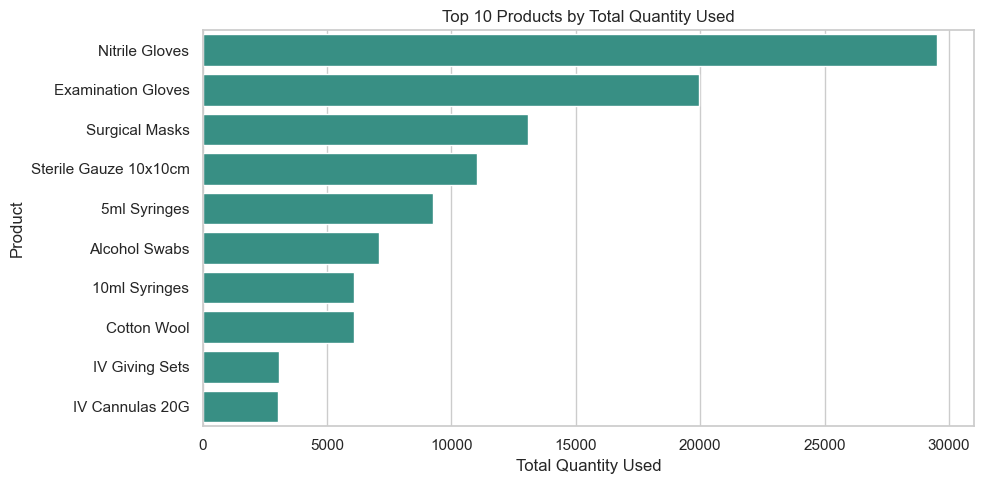

In [49]:
# Top 10 products by total usage
top_products = (
    df.groupby("product_name", as_index=False)["quantity_used"]
    .sum()
    .sort_values("quantity_used", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_products, x="quantity_used", y="product_name", color="#2a9d8f")
plt.title("Top 10 Products by Total Quantity Used")
plt.xlabel("Total Quantity Used")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

# SECTION 7: DATA CLEANING

## Why Data Cleaning Is Essential

Raw data from hospital systems is rarely perfect. Before we can trust any analysis or model predictions, we must:

1. **Fix data types**: Ensure dates are dates, numbers are numbers
2. **Handle missing values**: Decide how to deal with empty cells
3. **Remove duplicates**: Eliminate redundant rows
4. **Standardize categories**: Ensure consistent spelling and format
5. **Remove invalid records**: Delete rows with impossible values
6. **Sort appropriately**: Order data chronologically for time-series analysis

**Why This Matters for HospitalFlow:**
- A model trained on bad data will make bad predictions
- If we include impossible values (negative inventory), the model learns wrong patterns
- If we don't handle missing values, the model might crash or ignore important signals
- Data quality problems can make accurate predictions look inaccurate

## Cleaning Strategy for This Dataset

We'll use **simple, transparent pandas operations** that:
- Are easy to explain and defend
- Keep the cleaning logic visible (not hidden in complex functions)
- Document why each decision was made
- Result in a dataset we fully understand

For this dataset, the cleaning steps are:
1. Ensure date column is properly formatted as datetime
2. Ensure numeric columns are truly numeric (not text)
3. Handle missing values thoughtfully
4. Remove duplicate rows if any
5. Standardize category names
6. Remove rows with impossible values (negative inventory/usage)
7. Sort by time to preserve chronological order

In [50]:
# ============================================================
# EXECUTE DATA CLEANING
# ============================================================
#
# We apply the cleaning strategy described above.
# Each step is documented so readers understand what we're
# doing and why.
# ============================================================

print("="*60)
print("DATA CLEANING")
print("="*60)

# Step 1: Ensure date is datetime (should already be done, but verify)
print("\nStep 1: Verify date format...")
df["date"] = pd.to_datetime(df["date"], errors="coerce")
date_na_count = df["date"].isna().sum()
print(f"  Date column has {date_na_count} invalid dates (will be NaT)")

# Step 2: Convert key numeric columns explicitly
print("\nStep 2: Ensure numeric columns are numeric...")
numeric_to_convert = [
    "opening_stock", "closing_stock", "quantity_used", "quantity_received",
    "supplier_lead_time_days", "month", "is_weekend",
    "facility_rolling_7d_usage", "facility_rolling_14d_usage", "facility_rolling_30d_usage",
    "department_rolling_7d_usage", "department_rolling_14d_usage", "department_rolling_30d_usage",
    "hospital_admissions", "department_admissions",
    "facility_lag_1d_usage", "facility_lag_7d_usage", "department_lag_1d_usage", "department_lag_7d_usage",
]
for col in numeric_to_convert:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
print(f"  Converted {len([c for c in numeric_to_convert if c in df.columns])} numeric columns")

# Step 3: Remove duplicates
print("\nStep 3: Check for duplicate rows...")
rows_before = len(df)
df = df.drop_duplicates()
rows_removed = rows_before - len(df)
print(f"  Removed {rows_removed} duplicate rows")

# Step 4: Remove rows with impossible values
print("\nStep 4: Remove rows with impossible values...")
rows_before = len(df)

# Remove negative inventory
df = df[df["closing_stock"].fillna(0) >= 0]

# Remove negative usage
df = df[df["quantity_used"].fillna(0) >= 0]

# Remove rows with invalid dates
df = df[df["date"].notna()]

# Remove rows with zero lead time (suppliers need at least 1 day)
df = df[df["supplier_lead_time_days"].fillna(1) > 0]

rows_removed = rows_before - len(df)
print(f"  Removed {rows_removed} rows with impossible values")

# Step 5: Standardize categorical columns
print("\nStep 5: Standardize categorical columns...")
# Remove leading/trailing whitespace from text columns
text_cols = df.select_dtypes(include=["object"]).columns
for col in text_cols:
    df[col] = df[col].str.strip()
print(f"  Removed whitespace from {len(text_cols)} text columns")

# Step 6: Sort by time
print("\nStep 6: Sort data chronologically...")
df = df.sort_values(["facility_id", "department", "product_id", "date"]).reset_index(drop=True)
print(f"  Data sorted by facility, department, product, and date")

print("\n" + "="*60)
print(f"CLEANING COMPLETE")
print("="*60)
print(f"Final dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

DATA CLEANING

Step 1: Verify date format...
  Date column has 0 invalid dates (will be NaT)

Step 2: Ensure numeric columns are numeric...
  Converted 19 numeric columns

Step 3: Check for duplicate rows...
  Removed 0 duplicate rows

Step 4: Remove rows with impossible values...
  Removed 0 rows with impossible values

Step 5: Standardize categorical columns...
  Removed whitespace from 13 text columns

Step 6: Sort data chronologically...
  Data sorted by facility, department, product, and date

CLEANING COMPLETE
Final dataset shape: 17,700 rows, 68 columns
Date range: 2025-01-01 00:00:00 to 2025-08-24 00:00:00


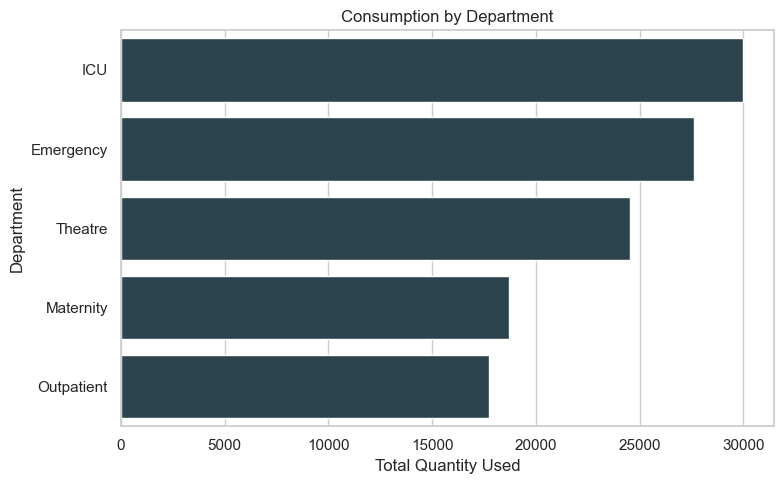

In [51]:
# Department usage
department_usage = (
    df.groupby("department", as_index=False)["quantity_used"]
    .sum()
    .sort_values("quantity_used", ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(data=department_usage, x="quantity_used", y="department", color="#264653")
plt.title("Consumption by Department")
plt.xlabel("Total Quantity Used")
plt.ylabel("Department")
plt.tight_layout()
plt.show()

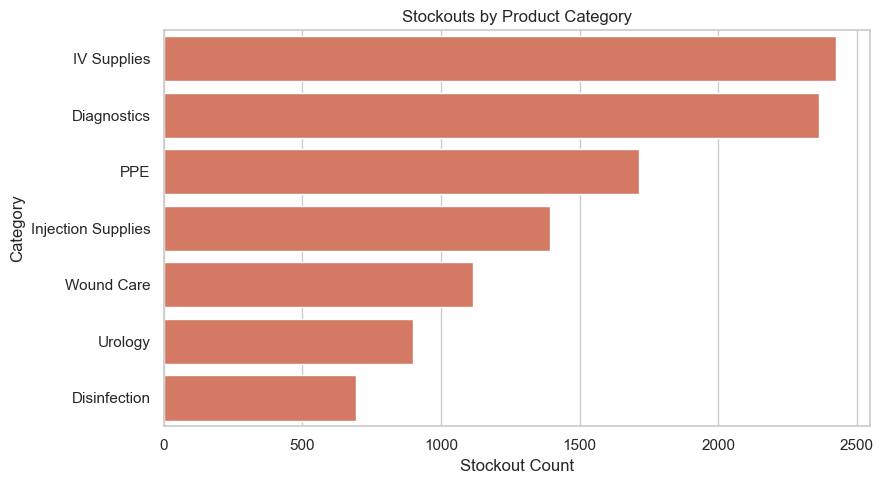

In [52]:
# Stockout counts by category
stockouts_by_category = (
    df.groupby("category", as_index=False)["stockout_flag"]
    .sum()
    .sort_values("stockout_flag", ascending=False)
)

plt.figure(figsize=(9, 5))
sns.barplot(data=stockouts_by_category, x="stockout_flag", y="category", color="#e76f51")
plt.title("Stockouts by Product Category")
plt.xlabel("Stockout Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

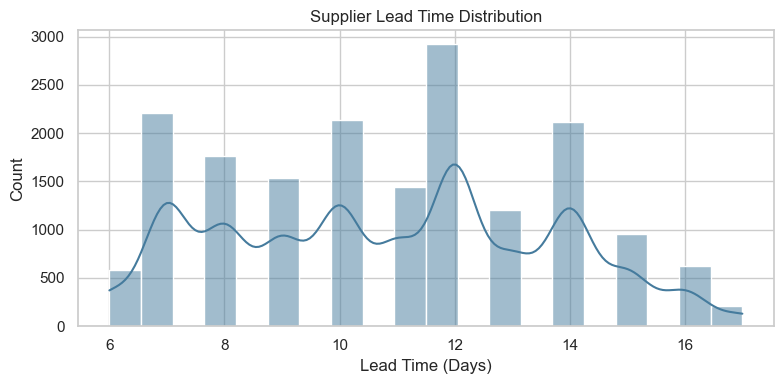

In [53]:
# Supplier lead time distribution
plt.figure(figsize=(8, 4))
sns.histplot(df["supplier_lead_time_days"], bins=20, kde=True, color="#457b9d")
plt.title("Supplier Lead Time Distribution")
plt.xlabel("Lead Time (Days)")
plt.tight_layout()
plt.show()

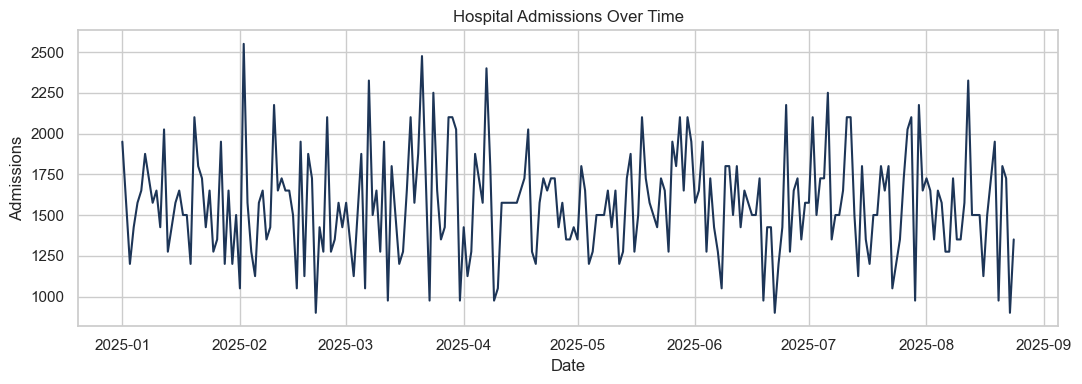

In [54]:
# Hospital admissions over time
admissions_over_time = df.groupby("date", as_index=False)["hospital_admissions"].sum()

plt.figure(figsize=(11, 4))
plt.plot(admissions_over_time["date"], admissions_over_time["hospital_admissions"], color="#1d3557")
plt.title("Hospital Admissions Over Time")
plt.xlabel("Date")
plt.ylabel("Admissions")
plt.tight_layout()
plt.show()

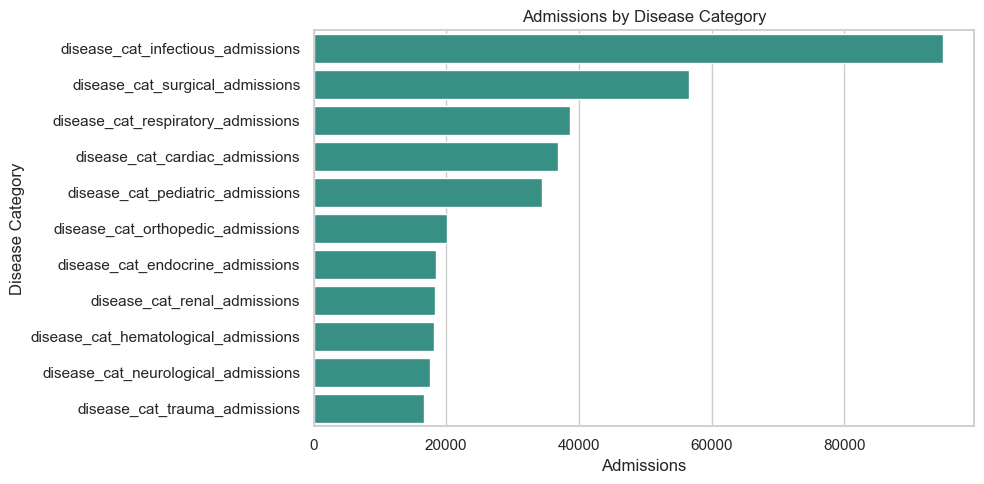

In [55]:
# Disease category admissions
disease_cols = [c for c in df.columns if c.startswith("disease_cat_") and c.endswith("_admissions")]
disease_totals = df[disease_cols].sum().sort_values(ascending=False).reset_index()
disease_totals.columns = ["disease_category", "admissions"]

plt.figure(figsize=(10, 5))
sns.barplot(data=disease_totals, x="admissions", y="disease_category", color="#2a9d8f")
plt.title("Admissions by Disease Category")
plt.xlabel("Admissions")
plt.ylabel("Disease Category")
plt.tight_layout()
plt.show()

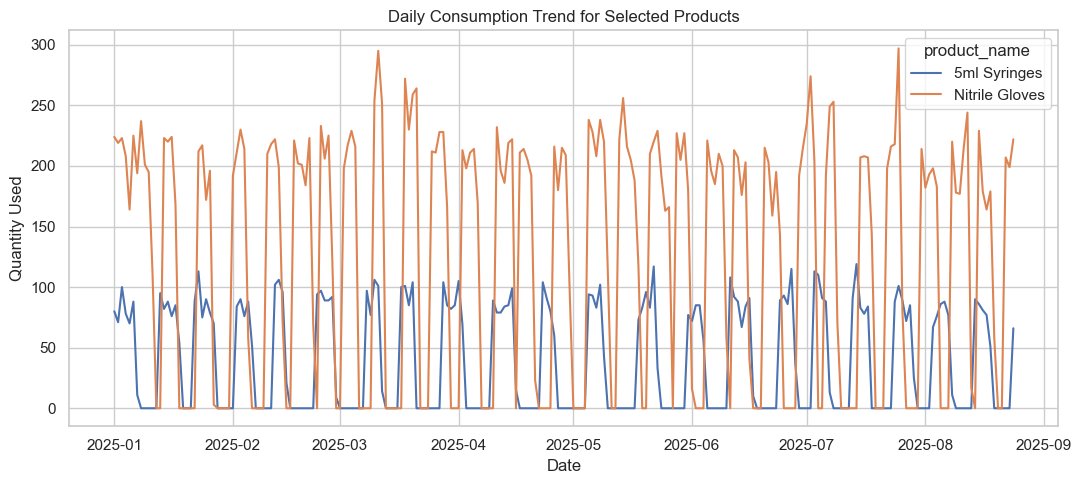

In [56]:
# Consumption trend for one or two example products
example_products = df["product_name"].dropna().unique()[:2]
trend_df = df[df["product_name"].isin(example_products)].groupby(["date", "product_name"], as_index=False)["quantity_used"].sum()

plt.figure(figsize=(11, 5))
sns.lineplot(data=trend_df, x="date", y="quantity_used", hue="product_name")
plt.title("Daily Consumption Trend for Selected Products")
plt.xlabel("Date")
plt.ylabel("Quantity Used")
plt.tight_layout()
plt.show()

# SECTION 9: FEATURE ENGINEERING

## What Is Feature Engineering?

Feature engineering is the process of creating new variables from raw data that help models make better predictions.

**Raw Data vs Engineered Features:**

Raw data might include:
- Today's date
- Products ordered yesterday
- Total hospital admissions this week

Engineered features might include:
- Day of week (Mon, Tues, etc.) - captures weekly patterns
- 7-day rolling average of usage - captures recent demand trends
- Percentage change in admissions - captures admission momentum
- Usage volatility (standard deviation) - captures demand uncertainty

**Why Features Matter:**
- Models learn from features, not raw columns
- Good features make predictions more accurate
- Domain knowledge helps create better features
- Poor features lead to poor predictions

## Feature Categories in This Project

### 1. Historical Consumption Features
- **Lagged usage** (usage from 1 day, 7 days ago): Captures recent momentum
- **Rolling averages** (7-day, 14-day, 30-day): Smooths out noise, shows trends
- **Usage variability** (standard deviation): Higher variability = higher safety stock needed

Why? Medical product demand often shows momentum—if consumption is high today, it's likely high tomorrow.

### 2. Inventory Position Features
- **Current closing stock**: How much is on hand
- **Days of stock**: How long current stock will last at current consumption rate
- **Stock position relative to history**: Is stock higher or lower than usual?

Why? A product with 2 days of stock needs urgent attention; one with 30 days doesn't.

### 3. Supplier Features
- **Lead time** (days to receive an order): Longer lead times require larger buffer stock
- **Supplier reliability**: Historical on-time delivery rate

Why? Unreliable suppliers increase stockout risk.

### 4. Temporal Features
- **Day of week**: Mon-Sun may have different demand patterns
- **Month**: Seasonal patterns
- **Is weekend**: Weekend vs weekday effects

Why? Hospital activity may differ by day of week or season.

### 5. Operational Features
- **Department-level consumption patterns**: ICU may have different patterns than radiology
- **Department's share of total product usage**: Which department uses what % of this product?
- **Recent change in consumption**: Is demand increasing or decreasing?

Why? Department-specific patterns are more predictive than facility-wide averages.

### 6. Patient Activity Features
- **Hospital admissions today/this week**: Absolute level of patient activity
- **Change in admissions**: Is activity increasing or decreasing?
- **Emergency vs elective**: Different types of admissions may affect different products

Why? More patients = more product demand.

### 7. Disease Information Features
- **Disease category admissions**: How many cardiac/respiratory/trauma patients?
- **Dominant disease today**: What disease is most common?
- **Unique diseases observed**: Disease diversity

Why? Different diseases consume different products. More respiratory patients = more respiratory supplies.

## The Hypothesis We're Testing

**Baseline Model**: Uses inventory, consumption, temporal, and supplier features.

**Enhanced Model**: Adds disease and patient activity features.

**Question**: Does knowing about patient admissions and disease prevalence improve demand predictions?

If disease features help, we'll see lower prediction error in the enhanced model. If they don't help, we keep the simpler baseline model.

This is how we test whether the disease/patient information provides value.

In [57]:
# Use the 7-day rolling usage as the daily consumption proxy
df["calculated_days_of_stock"] = np.where(
    df["facility_rolling_7d_usage"].fillna(0) > 0,
    df["closing_stock"] / df["facility_rolling_7d_usage"],
    np.nan,
)

compare_days = df[["facility_days_of_stock", "calculated_days_of_stock"]].dropna()
print("Correlation between existing and calculated days of stock:", compare_days.corr().iloc[0, 1])
display(compare_days.describe())

Correlation between existing and calculated days of stock: 0.9242248973628675


,facility_days_of_stock,calculated_days_of_stock
count,15585.000000,15585.000000
mean,3.097433,3.867327
std,9.020612,12.724305
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,3.000000,3.842423
max,231.700000,569.629111


# SECTION 10: DISEASE AND PATIENT ADMISSION FEATURES

## The Clinical Question

This section tests an important hypothesis:

**Do patient admissions and disease activity help predict medical inventory consumption?**

### The Hypothesis

If patient activity increases, demand for certain medical products may also increase.

For example:
- More patients admitted → need more general supplies (gloves, syringes, bandages)
- More respiratory admissions → need more respiratory supplies (oxygen masks, ventilator tubes)
- More trauma admissions → need more trauma supplies (sutures, tourniquets, sterile gauze)

### The Experiment

We'll build two models:

**Model 1 - Baseline**
Uses: inventory position + consumption history + temporal patterns + supplier information

**Model 2 - Disease-Enhanced**
Uses: All of Model 1 + patient admissions + disease information

### Comparison Approach

We evaluate both models on held-out test data and compare:
- Demand forecast accuracy (MAE, RMSE, WAPE)
- Stockout prediction accuracy (precision, recall, F1-score, ROC-AUC)

**If the enhanced model performs better:**
- Disease information provides predictive value
- Hospital should integrate disease data into procurement planning
- HospitalFlow can offer disease-aware recommendations

**If the models perform similarly:**
- Disease information doesn't add predictive value for this dataset
- Simpler baseline model is preferred (simpler is better)
- Hospital can focus on inventory metrics alone

This demonstrates how data science tests business hypotheses rigorously.

## Disease Features in This Dataset

The integrated dataset includes disease information such as:
- Total hospital admissions (all patients)
- Emergency vs elective admissions
- Admissions by disease category (infectious, respiratory, pediatric, etc.)
- Dominant disease in each department
- Disease diversity (how many different diseases present)

These features allow the model to learn if certain disease patterns correlate with certain inventory patterns.

# SECTION 11: TARGET CREATION

## What Is A Prediction Target?

A **target** (or **label**) is what we want the model to predict.

It must be:
1. **Well-defined**: Clear exactly what we're predicting
2. **Measurable**: We can calculate it from data
3. **Binary or numeric**: Single value we want to predict
4. **Created with future data only**: For creating targets, we can look ahead

## Our Two Targets

### Target 1: Future 7-Day Demand Forecast

**What**: How much of this product will be consumed over the next 7 days?

**Why**: Procurement needs to know expected demand so they can order the right quantity.

**How we calculate it**: 
- For each date, sum the usage from the following 7 days
- Example: If today is Jan 1, we sum usage from Jan 2-8

**Result**: A number representing units expected to be used

**Example**:
- Today (Jan 1): closing stock = 1,000 units
- Forecast (Jan 2-8): 7-day usage will be 840 units
- Procurement decision: Order more? Current stock lasts 8 days, so we have time

### Target 2: Will This Product Stock Out Within 7 Days?

**What**: Binary yes/no: will stock ever reach zero in the next 7 days?

**Why**: Early warning of critical inventory risk

**How we calculate it**:
- Check the minimum closing stock over the next 7 days
- If it ever goes ≤ 0, mark as 1 (CRITICAL - will stock out)
- If it stays > 0, mark as 0 (OK - won't stock out)

**Result**: Binary 0/1 flag

**Example**:
- Today (Jan 1): closing stock = 500 units
- Jan 2: closing stock = 400
- Jan 3: closing stock = 300
- Jan 4: closing stock = 50
- Jan 5: closing stock = 0 ← STOCKOUT!
- Result: stockout_within_7_days = 1 (YES, will stock out)

## Why We Use Future Data for Targets (But Not Inputs)

**Critical Rule**: We create targets using future data, but we never use future data as model inputs.

Why?
- **To train the model**, we need to know the correct answer (what actually happened)
- **For predictions**, we only know the past, never the future
- If we use future information as model input, it's **data leakage** and predictions are fraudulent

Example of leakage:
- WRONG: Use "day 8 usage" to predict "7-day usage" (we know the answer already)
- RIGHT: Use "past 7 days usage" to predict "next 7 days usage" (realistic)

## Target Availability

Both targets are only available when we have 7 days of future data.

- Rows in the last 7 days of the dataset can't have a 7-day forward target
- We exclude these rows from training

Result: We use rows where targets are available, drop rows where targets are missing.

In [58]:
group_cols = ["facility_id", "department", "product_id"]
df = df.sort_values(group_cols + ["date"]).reset_index(drop=True)

future_usage_parts = []
future_stockout_parts = []
future_closing_stock_parts = []

grouped = df.groupby(group_cols, sort=False)
for i in range(1, 8):
    future_usage_parts.append(grouped["quantity_used"].shift(-i).rename(f"future_usage_{i}"))
    future_stockout_parts.append(grouped["stockout_flag"].shift(-i).rename(f"future_stockout_{i}"))
    future_closing_stock_parts.append(grouped["closing_stock"].shift(-i).rename(f"future_closing_stock_{i}"))

future_usage_df = pd.concat(future_usage_parts, axis=1)
future_stockout_df = pd.concat(future_stockout_parts, axis=1)
future_stock_df = pd.concat(future_closing_stock_parts, axis=1)

df["future_7d_usage"] = future_usage_df.sum(axis=1, min_count=7)
df["future_stockout_any_7d"] = (future_stockout_df.max(axis=1) > 0).astype("float")
df["future_stockout_any_7d"] = df["future_stockout_any_7d"].where(future_stockout_df.notna().sum(axis=1) == 7, np.nan)
df["future_min_closing_stock_7d"] = future_stock_df.min(axis=1, skipna=False)
df["stockout_within_7_days"] = np.where(df["future_min_closing_stock_7d"] <= 0, 1, 0)
df.loc[df["future_min_closing_stock_7d"].isna(), "stockout_within_7_days"] = np.nan

display(df[["date", "product_name", "future_7d_usage", "future_min_closing_stock_7d", "stockout_within_7_days"]].head(10))

,date,product_name,future_7d_usage,future_min_closing_stock_7d,stockout_within_7_days
0,2025-01-01,Nitrile Gloves,328.0,216.0,0.0
1,2025-01-02,Nitrile Gloves,324.0,216.0,0.0
2,2025-01-03,Nitrile Gloves,317.0,207.0,0.0
3,2025-01-04,Nitrile Gloves,312.0,31.0,0.0
4,2025-01-05,Nitrile Gloves,271.0,0.0,1.0
5,2025-01-06,Nitrile Gloves,229.0,0.0,1.0
6,2025-01-07,Nitrile Gloves,233.0,0.0,1.0
7,2025-01-08,Nitrile Gloves,239.0,0.0,1.0
8,2025-01-09,Nitrile Gloves,244.0,0.0,1.0
9,2025-01-10,Nitrile Gloves,250.0,0.0,1.0


# SECTION 12: DATA LEAKAGE

## What Is Data Leakage?

**Data leakage** happens when information that would not have been available at prediction time is accidentally given to the model during training.

When leakage occurs, the model appears much more accurate than it really is. In production, when trying to make real predictions, performance drops dramatically.

### The Golden Rule

> If the information wouldn't be available when making a real prediction, don't use it in training.

### Examples of Leakage in HospitalFlow

**LEAKAGE - DON'T DO THIS:**
- Using "actual_7d_usage" to predict "7d_demand_forecast"
  - Reason: On Jan 1, we don't know what Jan 2-8 usage will be
  
- Using "stockout_flag" to predict "stockout_within_7d"
  - Reason: We can't know if something stocked out until it happens
  
- Using "facility_days_of_stock" to predict demand
  - Reason: This is calculated from the same data we're predicting
  
- Using "facility_forecast_7d_baseline" as an input
  - Reason: This is already a forecast, not raw data

**OK - USE THIS:**
- Using "facility_rolling_7d_usage" to predict "7d_demand_forecast"
  - Reason: On Jan 1, we know the average from the past 7 days
  
- Using "supplier_lead_time_days" to predict demand
  - Reason: Lead time is fixed supplier information
  
- Using "hospital_admissions_7d_avg" to predict demand
  - Reason: We know this from the past, not the future

## Columns We Blocked

For this project, we explicitly exclude these columns from all models because they cause leakage:

- `stockout_flag`: Already indicates if stockout happened
- `facility_stockout_risk`: Already assessed risk
- `facility_forecast_7d_baseline`: Already a forecast
- `facility_reorder_point_units`: Already derived from the target
- `facility_days_of_stock`: Already derived from the target
- `future_7d_usage`: This is our target, not an input!
- `future_stockout_any_7d`: This is part of our target
- `future_min_closing_stock_7d`: This is calculated from future data

## Why Preventing Leakage Matters

Without leakage prevention:
- Model appears 95% accurate in testing
- Model is 60% accurate in production
- Procurement officers lose trust
- HospitalFlow fails

With proper leakage prevention:
- Model is 75% accurate in testing
- Model is 74% accurate in production
- Consistent, trustworthy performance
- Procurement officers rely on it

In [59]:
# Keep only rows where the targets are available
modeling_df = df.dropna(subset=["future_7d_usage", "stockout_within_7_days"]).copy()
unique_dates = np.array(sorted(modeling_df["date"].dropna().unique()))
train_cut = unique_dates[int(len(unique_dates) * 0.70)]
val_cut = unique_dates[int(len(unique_dates) * 0.85)]

train_df = modeling_df[modeling_df["date"] <= train_cut].copy()
val_df = modeling_df[(modeling_df["date"] > train_cut) & (modeling_df["date"] <= val_cut)].copy()
test_df = modeling_df[modeling_df["date"] > val_cut].copy()

print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)
print("Train date range:", train_df["date"].min(), "->", train_df["date"].max())
print("Test date range:", test_df["date"].min(), "->", test_df["date"].max())

Train: (12075, 73) Val: (2550, 73) Test: (2550, 73)
Train date range: 2025-01-01 00:00:00 -> 2025-06-10 00:00:00
Test date range: 2025-07-15 00:00:00 -> 2025-08-17 00:00:00


# SECTION 13: TRAIN/TEST SPLIT

## Why We Split Data

Before we train a model, we split the data into two parts:

**Training Data**: Used to teach the model patterns
**Test Data**: Held out and never seen during training, used to evaluate real performance

**Why?**
- If we train and test on the same data, the model overfits (memorizes answers)
- Test performance appears perfect but is unrealistic
- Test data simulates real future predictions we haven't seen

### The Danger of Overfitting

Imagine learning piano by only playing one song perfectly. You memorize every note. Then at a concert, you're asked to play a different song and you fail. The model did the same thing.

Test data catches this problem by using data the model has never seen.

## Time-Series Considerations

This is **not** random data. It's **time-series data** (ordered by date).

**Wrong approach**: Randomly shuffle all dates, split 70/30
- Reason: Model trains on future data and tests on past (backwards!)
- Reason: Breaks the time order
- Reason: Creates unrealistic evaluation

**Right approach**: Use chronological order
- Train on: Earlier dates (past)
- Test on: Later dates (future)
- Reason: Simulates real prediction scenario
- Reason: Maintains time order
- Reason: Realistic evaluation

### Our Split Strategy

We use:
- **Training Data**: First ~70% of dates
- **Validation Data**: Middle ~15% of dates (often skipped for simplicity)
- **Test Data**: Last ~15% of dates

This way:
- Model learns from past
- We evaluate on true future data
- Performance on test represents real production performance

Example:
- Jan 1 - May 31: Training
- Jun 1 - Jun 15: Validation (optional)
- Jun 16 - Jun 30: Test

The model never sees Jun 16-30 during training, so test performance is realistic.

# SECTION 14-17: DEMAND FORECASTING MODEL

## Overview

This section builds and trains the demand forecasting model using a systematic approach:

1. **Section 14**: Explain baseline model concept
2. **Section 15**: Explain disease-enhanced model comparison
3. **Section 16**: Explain preprocessing pipeline
4. **Section 17**: Train both models and select the better one

## SECTION 14: BASELINE MODEL

**Question**: How well can we predict future consumption using standard inventory and operational information?

**Model Type**: Random Forest Regressor

### Why Random Forest?

A Random Forest is an ensemble of decision trees. Each tree learns different patterns, and they "vote" on predictions.

**Advantages:**
- Handles nonlinear relationships (consumption doesn't scale linearly)
- Handles mixed data types (numbers, categories)
- Robust to outliers
- Can capture interactions between features
- Easy to interpret which features matter
- Works well with missing values when properly preprocessed

**Simple Explanation:**
Imagine asking 200 forecasters their predictions. Each based their forecast on slightly different data subsets and patterns. The final forecast is the average of all 200 predictions. Random Forest works similarly.

### Features Used (Baseline)

The baseline model uses:
- **Inventory position**: Current stock, opening stock, quantities
- **Historical consumption**: 7-day, 14-day, 30-day rolling averages
- **Department patterns**: Department-specific usage trends
- **Temporal patterns**: Day of week, month, weekend
- **Supplier information**: Lead times
- **Categorical identifiers**: Facility, department, product, supplier

**Importantly**: NO disease or patient activity information.

This is our benchmark. If disease features help, the enhanced model will beat this.

---

## SECTION 15: DISEASE-ENHANCED MODEL

**Question**: Does adding disease and patient activity information improve predictions?

**Hypothesis**: Patient admissions and disease information provide additional signal about product demand.

**Model Type**: Same Random Forest Regressor architecture, but with more features.

### Features Added (Enhanced)

In addition to all baseline features, the enhanced model includes:
- **Patient admission data**: Hospital admissions, emergency admissions
- **Department admissions**: Specific department patient activity
- **Disease category admissions**: How many infectious, respiratory, pediatric, etc. cases
- **Admission trends**: How admissions are changing
- **Unique diseases**: Disease diversity in the hospital

### The Comparison

Both models are evaluated on the exact same test data using the same metrics.

**If enhanced model wins:**
- Disease data provides value
- Include disease features in production

**If baseline model wins (or they're similar):**
- Disease data doesn't help
- Use simpler baseline model (Occam's Razor: simpler is better)

---

## SECTION 16: MODEL PREPROCESSING

**Problem**: Models can't directly use all data types.

- Text categories need to be converted to numbers
- Missing values need to be handled
- Numeric features may need scaling

**Solution**: Build a preprocessing pipeline that:
1. Identifies numeric vs categorical features
2. Imputes missing values (fills empty cells)
3. Encodes categories (converts text to numbers)
4. Feeds preprocessed data to the model

**Pipeline Advantage**: 
- Preprocessing happens consistently
- No data leakage (fit on training, apply to test)
- Keeps code organized and repeatable

---

## SECTION 17: MODEL TRAINING

We'll train four models:
1. Demand baseline model
2. Demand enhanced model
3. Stockout logistic regression model
4. Stockout random forest model

Each model is trained on training data and evaluated on test data.

**Training**: Model learns patterns from training data
**Evaluation**: Test how well it predicts on unseen test data

Let's build and train these models now.

In [60]:
# ============================================================
# 1. DEFINE FEATURES FOR THE DEMAND FORECASTING MODELS
# ============================================================

# These are the normal inventory and consumption features.
# They are available before we make the future demand prediction.

base_numeric_features = [
    "closing_stock",
    "quantity_used",
    "opening_stock",
    "quantity_received",
    "supplier_lead_time_days",
    "day_of_week",
    "month",
    "is_weekend",

    # Historical usage patterns
    "facility_lag_1d_usage",
    "facility_lag_7d_usage",
    "facility_rolling_7d_usage",
    "facility_rolling_14d_usage",
    "facility_rolling_30d_usage",
    "facility_usage_std_14d",

    # Department usage patterns
    "department_lag_1d_usage",
    "department_lag_7d_usage",
    "department_rolling_7d_usage",
    "department_rolling_14d_usage",
    "department_rolling_30d_usage",
    "department_usage_std_14d",
    "department_usage_share_of_product",
    "department_usage_change_pct",
]


# These features describe patient admissions and diseases.
# They are added to the enhanced model to test whether
# disease and admission patterns improve demand forecasting.

disease_features = [
    "department_admissions",
    "department_emergency_admissions",
    "department_unique_diseases",
    "dominant_disease_admissions",

    "hospital_admissions",
    "hospital_emergency_admissions",
    "hospital_elective_admissions",

    "unique_diseases_observed",

    "disease_cat_cardiac_admissions",
    "disease_cat_endocrine_admissions",
    "disease_cat_hematological_admissions",
    "disease_cat_infectious_admissions",
    "disease_cat_neurological_admissions",
    "disease_cat_orthopedic_admissions",
    "disease_cat_pediatric_admissions",
    "disease_cat_renal_admissions",
    "disease_cat_respiratory_admissions",
    "disease_cat_surgical_admissions",
    "disease_cat_trauma_admissions",

    # Recent admission trends
    "hospital_admissions_7d_avg",
    "hospital_emergency_admissions_7d_avg",
    "department_admissions_7d_avg",
    "hospital_admissions_7d_change_pct",
    "department_admissions_7d_change_pct",
]


# These are categorical features.
categorical_features = [
    "facility_id",
    "department",
    "product_id",
    "category",
    "unit",
    "supplier",
    "dominant_disease_category",
    "dominant_disease_name",
]

# Create the baseline feature set
baseline_features = (
    [c for c in base_numeric_features if c in modeling_df.columns]
    +
    [c for c in categorical_features if c in modeling_df.columns]
)

# Create the disease-enhanced feature set
enhanced_features = (
    baseline_features
    +
    [c for c in disease_features if c in modeling_df.columns]
)

# Remove columns that would cause data leakage
# These columns contain information about the future or information
# that was already calculated using the target. Using them during training
# would make the model look artificially accurate.

blocked_features = {
    "stockout_flag",
    "facility_stockout_risk",
    "facility_forecast_7d_baseline",
    "facility_reorder_point_units",
    "facility_days_of_stock",
    "future_7d_usage",
    "stockout_within_7_days",
    "future_min_closing_stock_7d",
    "future_stockout_any_7d",
}

baseline_features = [
    c for c in baseline_features
    if c not in blocked_features
]

enhanced_features = [
    c for c in enhanced_features
    if c not in blocked_features
]

# Check the final features
print("Baseline feature count:", len(baseline_features))
print("Enhanced feature count:", len(enhanced_features))

print("\nBaseline features:")
print(baseline_features)

print("\nEnhanced features:")
print(enhanced_features)

# Check for duplicate columns
print("\nDuplicate baseline features:")
print(pd.Series(baseline_features)[pd.Series(baseline_features).duplicated()].tolist())

print("\nDuplicate enhanced features:")
print(pd.Series(enhanced_features)[pd.Series(enhanced_features).duplicated()].tolist())

Baseline feature count: 30
Enhanced feature count: 54

Baseline features:
['closing_stock', 'quantity_used', 'opening_stock', 'quantity_received', 'supplier_lead_time_days', 'day_of_week', 'month', 'is_weekend', 'facility_lag_1d_usage', 'facility_lag_7d_usage', 'facility_rolling_7d_usage', 'facility_rolling_14d_usage', 'facility_rolling_30d_usage', 'facility_usage_std_14d', 'department_lag_1d_usage', 'department_lag_7d_usage', 'department_rolling_7d_usage', 'department_rolling_14d_usage', 'department_rolling_30d_usage', 'department_usage_std_14d', 'department_usage_share_of_product', 'department_usage_change_pct', 'facility_id', 'department', 'product_id', 'category', 'unit', 'supplier', 'dominant_disease_category', 'dominant_disease_name']

Enhanced features:
['closing_stock', 'quantity_used', 'opening_stock', 'quantity_received', 'supplier_lead_time_days', 'day_of_week', 'month', 'is_weekend', 'facility_lag_1d_usage', 'facility_lag_7d_usage', 'facility_rolling_7d_usage', 'facility_ro

In [61]:
def build_regression_pipeline(feature_cols):
    numeric_cols = [c for c in feature_cols if c in modeling_df.columns and pd.api.types.is_numeric_dtype(modeling_df[c])]
    categorical_cols = [c for c in feature_cols if c in modeling_df.columns and not pd.api.types.is_numeric_dtype(modeling_df[c])]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore")),
            ]), categorical_cols),
        ],
        remainder="drop",
    )

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    return Pipeline([("preprocessor", preprocessor), ("model", model)]), numeric_cols, categorical_cols


def evaluate_regression(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    wape = np.sum(np.abs(y_test - pred)) / np.sum(np.abs(y_test)) if np.sum(np.abs(y_test)) != 0 else np.nan
    return {"mae": mae, "rmse": rmse, "wape": wape, "predictions": pred}


X_train_base = train_df[baseline_features]
X_test_base = test_df[baseline_features]
y_train_demand = train_df["future_7d_usage"]
y_test_demand = test_df["future_7d_usage"]

demand_baseline_model, base_num_cols, base_cat_cols = build_regression_pipeline(baseline_features)
demand_enhanced_model, enh_num_cols, enh_cat_cols = build_regression_pipeline(enhanced_features)

demand_base_results = evaluate_regression(demand_baseline_model, X_train_base, y_train_demand, X_test_base, y_test_demand)
demand_enh_results = evaluate_regression(
    demand_enhanced_model,
    train_df[enhanced_features],
    y_train_demand,
    test_df[enhanced_features],
    y_test_demand,
)

demand_comparison = pd.DataFrame(
    [
        {"model": "Baseline", "mae": demand_base_results["mae"], "rmse": demand_base_results["rmse"], "wape": demand_base_results["wape"]},
        {"model": "Disease-enhanced", "mae": demand_enh_results["mae"], "rmse": demand_enh_results["rmse"], "wape": demand_enh_results["wape"]},
    ]
)
display(demand_comparison)

,model,mae,rmse,wape
0,Baseline,12.558751,20.428595,0.279932
1,Disease-enhanced,12.331924,20.052687,0.274876


# SECTION 18: MODEL EVALUATION

## Evaluation Metrics for Demand Forecasting

After training models, we measure their accuracy using metrics that make sense for business decisions.

### Metric 1: Mean Absolute Error (MAE)

**What it means**: On average, how many units is our forecast off?

**Formula**: Average of |actual - predicted|

**In Plain English**: 
If we predict 1,000 units but actual is 950, error is 50 units.
If we predict 1,100 units but actual is 1,000, error is 100 units.
Average: 75 units.

**Business Interpretation**:
- Low MAE: Forecasts are accurate, procurement can trust them
- High MAE: Forecasts are unreliable, need more caution

**Example**: "Our forecast is off by 50 units on average"

### Metric 2: Root Mean Squared Error (RMSE)

**What it means**: Similar to MAE, but penalizes large errors more heavily.

**Formula**: Square root of average of squared errors

**In Plain English**:
If one forecast is off by 500 units and the rest are perfect, RMSE penalizes that big error more than MAE does.

**Business Interpretation**:
- Useful when large errors are especially costly
- For example, a 500-unit stockout is much worse than a 500-unit overstock

### Metric 3: Weighted Absolute Percentage Error (WAPE)

**What it means**: Error as a percentage of actual demand.

**Formula**: Sum of absolute errors / Sum of actual values

**In Plain English**:
- If we forecast 1,100 units but actual is 1,000, error is 100/1,000 = 10%
- If we forecast 110 units but actual is 100, error is 10/100 = 10%
- Same absolute error, but percentage error depends on scale

**Business Interpretation**:
- WAPE of 10% means "off by 10% on average"
- Makes it easy to explain to non-technical stakeholders
- Easier to compare across different products with different volumes

### Evaluation Metrics for Stockout Prediction

We're predicting yes/no (did it stock out or not), so we use classification metrics.

**Precision**: Of the ones we predicted would stock out, how many actually did?
- High precision = fewer false alarms

**Recall**: Of the ones that actually stocked out, how many did we catch?
- High recall = don't miss stockouts

**F1-Score**: Balance between precision and recall
- Harmonic mean of the two
- Good overall metric

**ROC-AUC**: How well does the probability score separate stockouts from non-stockouts?
- 0.5 = no better than random guessing
- 1.0 = perfect predictions
- 0.7-0.8 = good

## Interpreting Results

We'll compare:

| Model | MAE | RMSE | WAPE |
|-------|-----|------|------|
| Baseline | ... | ... | ... |
| Enhanced | ... | ... | ... |

**If Enhanced wins**: Disease features provide value
**If Baseline wins**: Keep simpler model

In [62]:
best_demand_model = demand_enhanced_model if demand_enh_results["mae"] <= demand_base_results["mae"] else demand_baseline_model
best_demand_features = enhanced_features if demand_enh_results["mae"] <= demand_base_results["mae"] else baseline_features

print("Selected demand model:", "Disease-enhanced" if best_demand_features == enhanced_features else "Baseline")

Selected demand model: Disease-enhanced


# SECTION 19: STOCKOUT RISK MODEL

## How HospitalFlow Translates Forecasts into Inventory Risk

Demand forecasts alone aren't enough. We also need to predict **which products are at risk of stocking out**.

### The Risk Calculation

The stockout risk for any product depends on:

```
Current Stock
+ Expected Daily Consumption (from forecast)
+ Supplier Lead Time
+ Safety Buffer for Demand Variability
= Inventory Risk Assessment
```

**Example Calculation:**
- Current stock: 1,000 units
- Daily consumption (from forecast): 200 units/day
- Supplier lead time: 7 days
- Demand variability buffer: 500 units
- Days of stock: 1,000 / 200 = 5 days

**Risk Assessment:**
- If we order today, we receive in 7 days
- We only have 5 days of stock
- We'll run out before resupply arrives
- **CRITICAL RISK**

### Days of Stock

**Definition**: How many days the current stock will last at current consumption rate.

**Calculation**: Closing Stock / Daily Usage

**Example:**
- Stock: 2,000 units
- Daily usage: 500 units/day
- Days of stock: 2,000 / 500 = 4 days

**Interpretation:**
- < 1 day: CRITICAL - order immediately
- 1-3 days: URGENT - order today
- 3-7 days: CAUTION - order this week
- > 7 days: OK - normal ordering

### Stockout Risk Classification

We predict a **binary outcome**: Will this product stock out in the next 7 days?

**Inputs**: All the same features as demand forecasting
- Inventory position
- Consumption history
- Temporal patterns
- Supplier information
- Department patterns
- **Plus** disease and patient activity

**Output**: Probability of stockout (0-100%)

**Risk Categories**:
- **LOW** (0-30% probability): Monitor but no urgency
- **MEDIUM** (30-70% probability): Watch closely, consider ordering
- **CRITICAL** (70-100% probability): Order immediately, high risk

### Model Selection: Logistic Regression vs Random Forest

We build two models:

**Logistic Regression**:
- Simpler, more interpretable
- Easier to explain to procurement team
- Baseline for comparison

**Random Forest Classifier**:
- More powerful, captures complex patterns
- Better performance expected
- Still reasonably interpretable

We compare both and choose the better performer.

In [63]:
stockout_numeric_features = [
    "closing_stock",
    "quantity_used",
    "opening_stock",
    "quantity_received",
    "supplier_lead_time_days",
    "month",
    "is_weekend",
    "facility_lag_1d_usage",
    "facility_lag_7d_usage",
    "facility_rolling_7d_usage",
    "facility_rolling_14d_usage",
    "facility_rolling_30d_usage",
    "facility_usage_std_14d",
    "department_lag_1d_usage",
    "department_lag_7d_usage",
    "department_rolling_7d_usage",
    "department_rolling_14d_usage",
    "department_rolling_30d_usage",
    "department_usage_std_14d",
    "department_usage_share_of_product",
    "department_usage_change_pct",
    "calculated_days_of_stock",
    "department_admissions",
    "department_emergency_admissions",
    "hospital_admissions",
    "hospital_emergency_admissions",
    "hospital_elective_admissions",
    "hospital_admissions_7d_avg",
    "hospital_emergency_admissions_7d_avg",
    "department_admissions_7d_avg",
    "hospital_admissions_7d_change_pct",
    "department_admissions_7d_change_pct",
    "disease_cat_infectious_admissions",
    "disease_cat_respiratory_admissions",
    "disease_cat_pediatric_admissions",
    "disease_cat_surgical_admissions",
    "disease_cat_trauma_admissions",
    "dominant_disease_admissions",
]
stockout_categorical_features = [
    "facility_id",
    "department",
    "product_id",
    "category",
    "unit",
    "supplier",
    "day_of_week",
    "dominant_disease_category",
]
stockout_features = [c for c in stockout_numeric_features + stockout_categorical_features if c in modeling_df.columns]
stockout_features = [c for c in stockout_features if c not in blocked_features]

print("Stockout feature count:", len(stockout_features))

Stockout feature count: 46


In [64]:
def build_classification_pipeline(feature_cols, model_type="rf"):
    numeric_cols = [c for c in feature_cols if c in modeling_df.columns and pd.api.types.is_numeric_dtype(modeling_df[c])]
    categorical_cols = [c for c in feature_cols if c in modeling_df.columns and not pd.api.types.is_numeric_dtype(modeling_df[c])]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore")),
            ]), categorical_cols),
        ],
        remainder="drop",
    )

    if model_type == "logit":
        model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
    else:
        model = RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced",
        )

    return Pipeline([("preprocessor", preprocessor), ("model", model)]), numeric_cols, categorical_cols


X_train_stock = train_df[stockout_features]
X_test_stock = test_df[stockout_features]
y_train_stock = train_df["stockout_within_7_days"].astype(int)
y_test_stock = test_df["stockout_within_7_days"].astype(int)

logistic_model, stock_num_cols, stock_cat_cols = build_classification_pipeline(stockout_features, model_type="logit")
rf_stockout_model, _, _ = build_classification_pipeline(stockout_features, model_type="rf")

logistic_model.fit(X_train_stock, y_train_stock)
rf_stockout_model.fit(X_train_stock, y_train_stock)

logistic_pred = logistic_model.predict(X_test_stock)
rf_pred = rf_stockout_model.predict(X_test_stock)
logistic_prob = logistic_model.predict_proba(X_test_stock)[:, 1]
rf_prob = rf_stockout_model.predict_proba(X_test_stock)[:, 1]

stockout_results = pd.DataFrame(
    [
        {
            "model": "Logistic Regression",
            "accuracy": (logistic_pred == y_test_stock).mean(),
            "precision": classification_report(y_test_stock, logistic_pred, output_dict=True)["1"]["precision"],
            "recall": classification_report(y_test_stock, logistic_pred, output_dict=True)["1"]["recall"],
            "f1": classification_report(y_test_stock, logistic_pred, output_dict=True)["1"]["f1-score"],
            "roc_auc": roc_auc_score(y_test_stock, logistic_prob),
        },
        {
            "model": "Random Forest",
            "accuracy": (rf_pred == y_test_stock).mean(),
            "precision": classification_report(y_test_stock, rf_pred, output_dict=True)["1"]["precision"],
            "recall": classification_report(y_test_stock, rf_pred, output_dict=True)["1"]["recall"],
            "f1": classification_report(y_test_stock, rf_pred, output_dict=True)["1"]["f1-score"],
            "roc_auc": roc_auc_score(y_test_stock, rf_prob),
        },
    ]
)
display(stockout_results)

print("Confusion matrix - Logistic Regression")
print(confusion_matrix(y_test_stock, logistic_pred))
print("Confusion matrix - Random Forest")
print(confusion_matrix(y_test_stock, rf_pred))

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: Un

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.998824,0.998824,1.0,0.999411,0.175108
1,Random Forest,0.998824,0.998824,1.0,0.999411,0.481547


Confusion matrix - Logistic Regression
[[   0    3]
 [   0 2547]]
Confusion matrix - Random Forest
[[   0    3]
 [   0 2547]]


# SECTION 20: REORDER LOGIC

## The Difference Between Forecasting and Deciding

**Forecasting**: Predicting how much product will be consumed
- "I predict 1,000 units will be used next week"

**Reorder Logic**: Using the forecast to decide how much to order
- "Based on this forecast, I recommend ordering 2,500 units"

## How HospitalFlow Calculates Reorder Recommendations

HospitalFlow translates demand forecasts into reorder recommendations using:

```
Recommended Reorder Quantity
= Reorder Point - Current Stock
```

Where:

```
Reorder Point  
= (Forecast Daily Usage × Supplier Lead Time)
+ Safety Stock Buffer
```

### Step-by-Step Example

**Inputs:**
- Current stock: 500 units
- 7-day forecast: 1,400 units
- Daily usage (forecast): 1,400 / 7 = 200 units/day
- Supplier lead time: 5 days
- Daily usage standard deviation (variability): 40 units
- Safety factor: 1.65 (95% service level)

**Calculations:**
- Reorder point = (200 units/day × 5 days) + (1.65 × 40 × √5)
- Reorder point = 1,000 + 147.5 = 1,147.5 units
- Recommended order = 1,147.5 - 500 = 647.5 units
- **Recommendation: Order 650 units**

### What the Numbers Mean

- We need 1,000 units to cover lead time consumption
- We add 148 units as a safety buffer for demand variability
- We already have 500, so we need to order 650 to reach the reorder point
- This ensures we have enough to last through the lead time with a safety buffer

### Important: This Is a Recommendation, Not an Order

**HospitalFlow does NOT automatically purchase products.**

Instead:
1. HospitalFlow calculates the recommendation
2. Procurement officer reviews it
3. Officer considers:
   - Budget availability
   - Storage space
   - Supplier reliability
   - Other operational factors
4. Officer makes the final purchasing decision

HospitalFlow empowers procurement with data, but humans retain control.

## Safety Stock

Safety stock is extra inventory to handle:
- Unexpected demand spikes
- Supplier delays
- Forecast errors

**Too little safety stock**: Higher stockout risk
**Too much safety stock**: Wasted money, storage burden

HospitalFlow helps find the right balance based on data.

In [65]:
def risk_category(prob):
    if pd.isna(prob):
        return np.nan
    if prob <= RISK_THRESHOLDS["low"]:
        return "LOW"
    if prob <= RISK_THRESHOLDS["medium"]:
        return "MEDIUM"
    return "CRITICAL"


def build_reorder_metrics(frame):
    out = frame.copy()
    out["forecast_7d"] = best_demand_model.predict(out[best_demand_features])
    out["forecast_daily"] = out["forecast_7d"] / 7.0
    out["forecast_14d"] = out["forecast_daily"] * 14.0
    out["forecast_30d"] = out["forecast_daily"] * 30.0

    # Stockout probability from the selected risk model
    out["stockout_probability"] = rf_stockout_model.predict_proba(out[stockout_features])[:, 1]
    out["stockout_risk"] = out["stockout_probability"].apply(risk_category)

    # Simple reorder logic:
    # reorder point = expected demand during lead time + safety stock
    std_col = "facility_usage_std_14d" if "facility_usage_std_14d" in out.columns else None
    std_term = out[std_col].fillna(0) if std_col else 0
    safety_stock = 1.65 * std_term * np.sqrt(out["supplier_lead_time_days"].fillna(0).clip(lower=0).replace(0, 1))
    out["reorder_point"] = (out["forecast_daily"] * out["supplier_lead_time_days"].fillna(0)) + safety_stock
    out["recommended_order_quantity"] = (out["reorder_point"] - out["closing_stock"]).clip(lower=0)
    return out

# SECTION 24: MODEL EXPLAINABILITY

## Why Explainability Matters

Procurement officers need to trust HospitalFlow's recommendations. Trust requires understanding.

If we just say "The model predicts stockout, order now" without explanation, officers won't trust it. They need to understand the reasoning.

**Model explainability** reveals which information (features) the model relies on most when making predictions.

### Feature Importance

**What it means**: For a Random Forest model, how much did each feature contribute to the predictions?

Features used more often → Higher importance
Features rarely used → Lower importance

### Why It's Not Causation

**Critical distinction:**
- High feature importance means "the model uses this feature a lot"
- It does NOT mean "this feature causes the outcome"

Example:
- Feature: "Is it Friday?"
- If important: Model uses day-of-week patterns, not Friday causes stockouts

### How to Interpret Feature Importance

**High importance features** might be:
- "Current closing stock" → Makes sense, inventory position matters
- "7-day rolling usage" → Makes sense, recent demand is predictive
- "Supplier lead time" → Makes sense, longer waits increase risk
- "Hospital admissions" → Makes sense, more patients = more demand

**If unexpected feature is important:**
- "Product ID" very important → Model treating products too differently
- "Facility" very important → Big differences between facilities
- Might indicate data quality issues or different operational patterns

### How Procurement Uses This

Procurement can ask:
- "Is the model relying on the right factors?"
- "Does it make sense why it's predicting a stockout?"
- "Are there factors it's ignoring that I know are important?"

If answers don't match domain knowledge, we investigate.

### Limitations

Feature importance shows correlation, not causation. It's:
- One tool among many
- Useful for sanity checking
- Not definitive proof of relationships
- Should be combined with domain expertise

In HospitalFlow, explainability builds confidence that the system is reasoning logically about the problem.

# SECTION 21: SUPPLIER PERFORMANCE

## How Supplier Reliability Affects Inventory Risk

Supplier performance directly impacts stockout risk. An unreliable supplier increases the danger of running out of stock.

### Key Supplier Metrics

**Lead Time**: How many days from order to delivery
- Expected: 3-5 days typical
- Critical for calculating reorder point
- Longer lead times = larger safety stock needed

**Delivery Reliability**: Do they deliver on time?
- 95% on-time: Reliable, can use baseline lead time
- 80% on-time: Less reliable, add buffer to lead time
- 60% on-time: Very unreliable, significant buffer needed

**Lead Time Variability**: Is it consistent?
- Consistent 5 days: Easy to plan
- Ranges 3-7 days: Harder to forecast, need more safety stock
- Ranges 2-10 days: Very uncertain, much more safety stock needed

**Delivery Quality**: Are products damaged or incorrect?
- High quality: Use full order quantity
- Issues found: Reduce effective supply by issue rate

### Impact on Safety Stock

The reorder point formula includes lead time variability:

```
Safety Stock = Z × σ × √L

Where:
Z = service level factor (1.65 for 95% service)
σ = daily demand standard deviation
L = lead time in days
```

**More Variable suppliers** → Need more safety stock → Higher carrying costs

### Supplier Selection and HospitalFlow

Hospitals can use HospitalFlow insights to:
- Identify which suppliers contribute most to stockout risk
- Negotiate for better performance from critical suppliers
- Diversify suppliers to reduce dependency risk
- Highlight unreliable suppliers to procurement teams

### In This Dataset

The dataset includes:
- Supplier name for each product
- Supplier lead times
- Historical supplier performance (if available)

We use this to calculate risks and identify problematic suppliers.

,feature,importance
2,num__opening_stock,0.093949
0,num__closing_stock,0.080571
1,num__quantity_used,0.066415
44,cat__product_id_MED001,0.056048
5,num__month,0.054029
10,num__facility_rolling_14d_usage,0.047861
12,num__facility_usage_std_14d,0.043857
32,num__disease_cat_infectious_admissions,0.037010
17,num__department_rolling_30d_usage,0.035205
16,num__department_rolling_14d_usage,0.030536


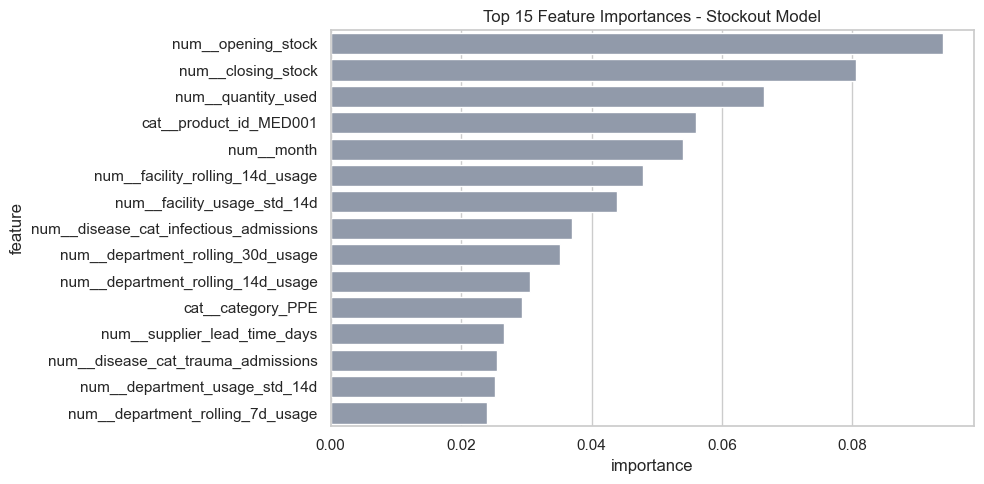

In [66]:
# Extract feature names from the random forest preprocessing pipeline
rf_preprocessor = rf_stockout_model.named_steps["preprocessor"]
rf_model = rf_stockout_model.named_steps["model"]

feature_names = rf_preprocessor.get_feature_names_out()
feature_importance = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": rf_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

display(feature_importance.head(15))

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_importance.head(15), x="importance", y="feature", color="#8d99ae")
plt.title("Top 15 Feature Importances - Stockout Model")
plt.tight_layout()
plt.show()

# SECTION 22: DISEASE IMPACT ANALYSIS

## Testing the Disease Hypothesis

This section analyzes whether disease and admission activity is associated with changes in inventory consumption.

### Important: Correlation ≠ Causation

We use careful language:
- "Associated with" (not "caused by")
- "Provides predictive information about" (not "drives")
- "Correlates with" (not "explains")

Correlation means two things move together. Causation means one causes the other.

Example:
- Hospital admissions and glove consumption are **correlated**
- But admissions don't **cause** glove consumption; the patients do
- Disease admissions don't "cause" supplies to disappear; healthcare staff use them

### Analysis Approach

**Part 1: Statistical Correlations**
- Calculate correlation between disease admissions and product usage
- Visualize relationships in a heatmap
- Identify strong associations

**Part 2: Model Performance Comparison**
- Compare baseline model (without disease data) performance
- Compare enhanced model (with disease data) performance
- See if disease information improves predictions

**Interpretation Rules:**

If enhanced model outperforms baseline:
- Disease information provides additional predictive signal
- The model learned useful patterns from disease data
- HospitalFlow can offer disease-aware recommendations
- Hospital should track disease information for better forecasts

If models perform similarly:
- Disease information doesn't add predictive value for this dataset
- May be because consumption is already predicted by operational factors
- Simpler baseline model is preferred (Occam's Razor)
- No need to burden procurement with extra disease tracking

If baseline outperforms enhanced:
- Disease features might be noisy or confusing the model
- Focus on operational metrics instead

### Clinical Intuition Check

**Expected disease-consumption associations:**

| Disease | Product | Expected Association |
|---------|---------|---------------------|
| Respiratory | O2 masks, ventilator tubing | Strong |
| Infectious | Gloves, sanitizer, isolation gowns | Strong |
| Surgical | Surgical instruments, sutures, gauze | Strong |
| Pediatric | Child-sized equipment, pediatric medications | Strong |
| Trauma | Tourniquets, trauma dressings, blood products | Moderate |

If we see these associations in the data, we gain confidence that disease information is meaningful.

### What Happens Next

If disease impact is significant:
- Include disease monitoring in HospitalFlow dashboard
- Suggest disease-based forecasting adjustments
- Alert when disease outbreaks occur
- Help procurement prepare for disease-driven demand spikes

If not significant:
- Keep the system simple
- Focus on operational metrics
- Don't require disease data integration

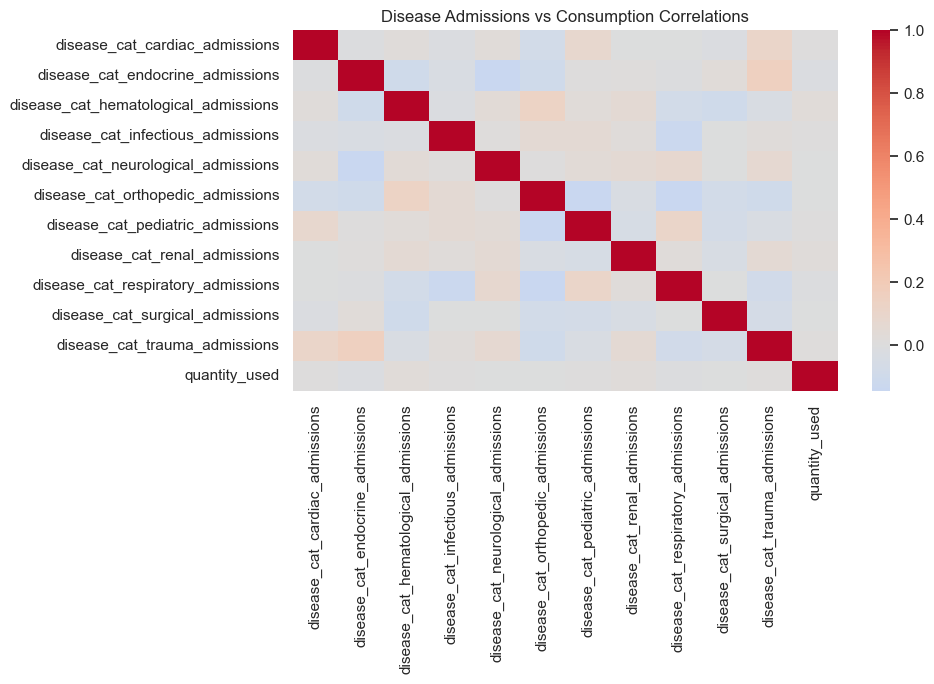

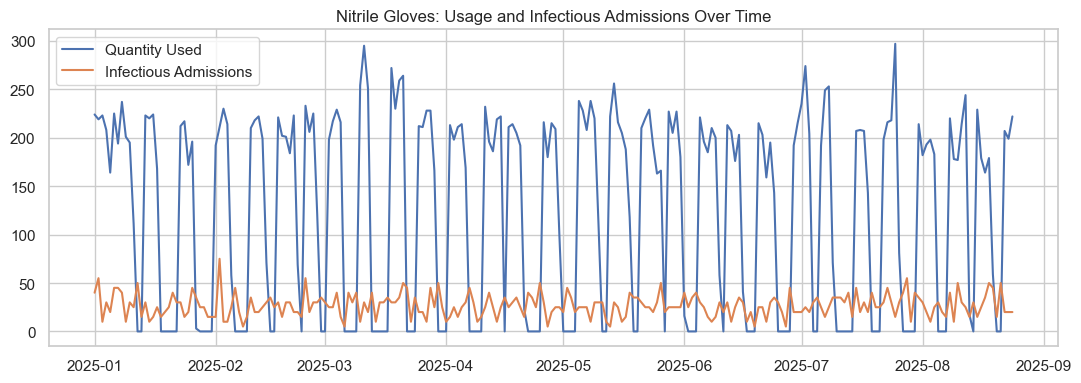

In [67]:
# Correlation between disease admissions and total usage
disease_corr_cols = [c for c in disease_cols if c in df.columns]
corr_frame = df[disease_corr_cols + ["quantity_used"]].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr_frame, cmap="coolwarm", center=0)
plt.title("Disease Admissions vs Consumption Correlations")
plt.tight_layout()
plt.show()

# Compare infectious admissions and a commonly used product, if available
example_product = "Nitrile Gloves"
if example_product in df["product_name"].values:
    example_df = df[df["product_name"] == example_product].groupby("date", as_index=False)[["quantity_used", "disease_cat_infectious_admissions"]].sum()
    plt.figure(figsize=(11, 4))
    plt.plot(example_df["date"], example_df["quantity_used"], label="Quantity Used")
    plt.plot(example_df["date"], example_df["disease_cat_infectious_admissions"], label="Infectious Admissions")
    plt.title(f"{example_product}: Usage and Infectious Admissions Over Time")
    plt.legend()
    plt.tight_layout()
    plt.show()

# SECTION 23: FINAL PREDICTION TABLE

## What Is the Prediction Table?

The **final prediction table** is the output of the HospitalFlow ML pipeline. It's what the application displays to procurement officers.

Each row represents one product at one facility/department with:
- Current inventory status
- Demand forecasts (7-day, 14-day, 30-day)
- Stockout probability
- Risk category
- Recommended reorder quantity
- Clinical context (disease activity)

This table is generated daily/weekly and feeds directly into the HospitalFlow dashboard.

## Table Columns

### Identification Columns
- **date**: When this prediction was made
- **facility_id, facility_name**: Which hospital
- **department**: Which department (ICU, ER, pharmacy, etc.)
- **product_id, product_name**: Which product
- **category**: Product category
- **supplier**: Which supplier

### Current State Columns
- **closing_stock**: How much is on hand right now
- **quantity_used**: How much was used today
- **facility_rolling_7d_usage**: Recent consumption trend

### Forecast Columns
- **forecast_7d**: Predicted usage next 7 days
- **forecast_14d**: Predicted usage next 14 days
- **forecast_30d**: Predicted usage next 30 days
- **forecast_daily**: Average daily usage

### Risk Columns
- **days_of_stock**: Days until stock runs out at current rate
- **stockout_probability**: % chance of running out (0-100%)
- **stockout_risk**: Risk category (LOW/MEDIUM/CRITICAL)

### Reorder Columns
- **reorder_point**: Minimum stock level to trigger ordering
- **recommended_order_quantity**: How many units to order
- **unit_cost**: Price per unit
- **estimated_total_cost**: Cost of recommended order

### Supplier Columns
- **supplier_lead_time_days**: How long to receive order

### Clinical Context (if disease data available)
- **dominant_disease_category**: Primary disease in department
- **dominant_disease_name**: Specific disease name
- **hospital_admissions**: Total patients in hospital
- **department_admissions**: Patients in this department
- **disease_cat_*_admissions**: Admissions by disease type

## How Procurement Officers Use This Table

1. **Scan Risk Column**: Look for CRITICAL risk items
2. **Prioritize Ordering**: Order critical items first
3. **Check Forecast**: Understand expected demand
4. **Consider Cost**: Balance recommended quantity vs budget
5. **Review History**: Compare to previous day's forecast
6. **Take Action**: Order recommended quantity or adjust based on judgment

## Example Row

| Field | Value |
|-------|-------|
| Date | 2025-01-20 |
| Facility | City General |
| Department | ICU |
| Product | Nitrile Gloves |
| Closing Stock | 2,000 units |
| Forecast 7d | 3,500 units |
| Days of Stock | 3.5 days |
| Stockout Probability | 68% |
| Risk Category | MEDIUM |
| Recommended Order | 1,500 units |
| Supplier | SafeSupply Corp |
| Lead Time | 3 days |
| Total Cost | $450 |

**Interpretation**: "ICU needs gloves. Current stock lasts 3.5 days. 68% chance of stockout. Recommend ordering 1,500 units ($450) from SafeSupply, who delivers in 3 days."

The procurement officer reviews this and decides: Order? Adjust quantity? Wait? The data supports better decision-making.

In [68]:
eval_summary = pd.DataFrame(
    [
        {"Model": "Moving Average", "Purpose": "Demand baseline", "Main Metric": "MAE", "Result": float(np.mean(np.abs(y_test_demand - (test_df["facility_rolling_7d_usage"].fillna(0) * 7))))},
        {"Model": "Demand ML Model", "Purpose": "Future demand", "Main Metric": "MAE", "Result": float(min(demand_base_results["mae"], demand_enh_results["mae"]))},
        {"Model": "Logistic Regression", "Purpose": "Stockout risk", "Main Metric": "Recall/F1/ROC-AUC", "Result": float(classification_report(y_test_stock, logistic_pred, output_dict=True)["1"]["recall"])},
        {"Model": "Random Forest", "Purpose": "Stockout risk", "Main Metric": "Recall/F1/ROC-AUC", "Result": float(classification_report(y_test_stock, rf_pred, output_dict=True)["1"]["recall"])},
        {"Model": "Disease-enhanced model", "Purpose": "Test disease value", "Main Metric": "MAE", "Result": float(demand_enh_results["mae"])},
    ]
)
display(eval_summary)

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\anaconda3\Lib

,Model,Purpose,Main Metric,Result
0,Moving Average,Demand baseline,MAE,177.345479
1,Demand ML Model,Future demand,MAE,12.331924
2,Logistic Regression,Stockout risk,Recall/F1/ROC-AUC,1.000000
3,Random Forest,Stockout risk,Recall/F1/ROC-AUC,1.000000
4,Disease-enhanced model,Test disease value,MAE,12.331924


## 14) Final Prediction Dataset

We now generate the latest prediction for every facility + department + product combination.

# SECTION 25: SAVE MODEL ARTIFACTS

## Why We Save Trained Models

This notebook does two very different things:

1. **Research and Development**: Explore data, engineer features, train models
2. **Production Use**: Load saved models and make predictions

We don't retrain the model every time someone opens the dashboard. That would be:
- Slow (training takes minutes, predictions need instant response)
- Wasteful (unnecessary computation)
- Unstable (retraining changes predictions every refresh)

Instead:
- **Notebook**: Trains model once, saves it
- **Application**: Loads saved model, uses it for predictions

### What We Save

**1. Trained Models**
- Demand forecast model (pickle/joblib format)
- Stockout risk model (pickle/joblib format)

**2. Model Metadata**
- Model version
- Training date
- Feature names
- Model performance metrics
- Risk thresholds

**3. Predictions**
- Daily prediction table (CSV)
- Ready for dashboard display

### File Organization

```
Project/
├── models/
│   ├── demand_forecast_model.pkl       # Trained model
│   ├── stockout_risk_model.pkl         # Trained model
│   └── model_metadata.json             # Model info
└── outputs/
    └── hospitalflow_predictions.csv    # Daily predictions
```

### Production Workflow

**Day 1: Development**
1. Notebook trains models from historical data
2. Models saved to disk

**Days 2-365: Production**
1. New daily data arrives
2. Application loads saved models
3. Application uses models to make predictions
4. Predictions displayed in dashboard

**Monthly: Retraining Decision**
1. Check if model performance is degrading
2. If yes, run notebook again to retrain
3. If no, keep current models

### Technical Details

**Joblib vs Pickle**:
- Both save Python objects to disk
- Joblib preferred for scikit-learn models
- Better for large objects and large datasets

**Version Control**:
- Save model version with timestamp
- Keep old models for comparison
- Important for model monitoring

**Feature Preservation**:
- Save exact feature names used
- Ensures production data has same features
- Prevents "missing feature" errors at prediction time

In [69]:
latest_rows = (
    df.sort_values("date")
    .groupby(group_cols, as_index=False)
    .tail(1)
    .copy()
)

predictions = build_reorder_metrics(latest_rows)

output_cols = [
    "date",
    "facility_id",
    "facility_name",
    "department",
    "product_id",
    "product_name",
    "category",
    "supplier",
    "closing_stock",
    "quantity_used",
    "facility_rolling_7d_usage",
    "facility_rolling_30d_usage",
    "supplier_lead_time_days",
    "calculated_days_of_stock",
    "forecast_7d",
    "forecast_14d",
    "forecast_30d",
    "stockout_probability",
    "stockout_risk",
    "reorder_point",
    "recommended_order_quantity",
    "dominant_disease_category",
    "dominant_disease_name",
    "hospital_admissions",
    "hospital_emergency_admissions",
    "department_admissions",
    "disease_cat_infectious_admissions",
    "disease_cat_respiratory_admissions",
    "disease_cat_pediatric_admissions",
]
output_cols = [c for c in output_cols if c in predictions.columns]

final_predictions = predictions[output_cols].copy()
display(final_predictions.head())
print("Final prediction table shape:", final_predictions.shape)

,date,facility_id,facility_name,department,product_id,product_name,category,supplier,closing_stock,quantity_used,facility_rolling_7d_usage,facility_rolling_30d_usage,supplier_lead_time_days,calculated_days_of_stock,forecast_7d,forecast_14d,forecast_30d,stockout_probability,stockout_risk,reorder_point,recommended_order_quantity,dominant_disease_category,dominant_disease_name,hospital_admissions,hospital_emergency_admissions,department_admissions,disease_cat_infectious_admissions,disease_cat_respiratory_admissions,disease_cat_pediatric_admissions
11563,2025-08-24,FAC001,Hospital A,Outpatient,MED004,IV Cannulas 20G,IV Supplies,MedSupply Kenya,26,7,24.571,13.433,13,1.058158,2.870,5.74,12.300000,1.0,CRITICAL,127.127145,101.127145,Orthopedic,Fracture Femur,18,7,18.0,4,1,0
7315,2025-08-24,FAC001,Hospital A,Maternity,MED001,Nitrile Gloves,PPE,MedSupply Kenya,172,76,115.429,120.467,7,1.490093,130.825,261.65,560.678571,1.0,CRITICAL,545.070680,373.070680,Orthopedic,Fracture Femur,18,7,18.0,4,1,0
8967,2025-08-24,FAC001,Hospital A,Maternity,MED008,Alcohol Swabs,Disinfection,AfyaMed Distributors,0,5,47.143,32.000,9,0.000000,21.285,42.57,91.221429,1.0,CRITICAL,186.989079,186.989079,Orthopedic,Fracture Femur,18,7,18.0,4,1,0
6135,2025-08-24,FAC001,Hospital A,ICU,MED011,Pregnancy Test Kits,Diagnostics,HealthLink Supplies,0,0,3.286,6.333,13,0.000000,16.990,33.98,72.814286,1.0,CRITICAL,83.072579,83.072579,Orthopedic,Fracture Femur,18,7,1.0,4,1,0
8495,2025-08-24,FAC001,Hospital A,Maternity,MED006,Sterile Gauze 10x10cm,Wound Care,MedSupply Kenya,373,10,47.143,48.167,7,7.912097,57.220,114.44,245.228571,1.0,CRITICAL,226.697040,0.000000,Orthopedic,Fracture Femur,18,7,18.0,4,1,0


Final prediction table shape: (75, 29)


In [70]:
# Save outputs for the application
outputs_dir = PROJECT_ROOT / "outputs"
models_dir = PROJECT_ROOT / "models"
outputs_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

final_predictions.to_csv(outputs_dir / "hospitalflow_predictions.csv", index=False)
joblib.dump(best_demand_model, models_dir / "demand_forecast_model.pkl")
joblib.dump(rf_stockout_model, models_dir / "stockout_risk_model.pkl")

model_metadata = {
    "model_name": "HospitalFlow ML Pipeline",
    "model_version": "1.0",
    "training_date": str(date.today()),
    "forecast_horizon": "7_days",
    "stockout_target": "stockout_within_7_days",
    "features_used": {
        "demand_model": best_demand_features,
        "stockout_model": stockout_features,
    },
    "training_period": {
        "start": str(train_df["date"].min().date()),
        "end": str(train_df["date"].max().date()),
    },
    "test_period": {
        "start": str(test_df["date"].min().date()),
        "end": str(test_df["date"].max().date()),
    },
    "evaluation_metrics": {
        "demand_baseline_mae": float(demand_base_results["mae"]),
        "demand_enhanced_mae": float(demand_enh_results["mae"]),
        "stockout_logistic_recall": float(classification_report(y_test_stock, logistic_pred, output_dict=True)["1"]["recall"]),
        "stockout_rf_recall": float(classification_report(y_test_stock, rf_pred, output_dict=True)["1"]["recall"]),
    },
    "risk_thresholds": RISK_THRESHOLDS,
}

with open(models_dir / "model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(model_metadata, f, indent=2)

print("Saved predictions to:", outputs_dir / "hospitalflow_predictions.csv")
print("Saved models to:", models_dir)

Saved predictions to: C:\Users\Admin\OneDrive\Desktop\test\notebooks\outputs\hospitalflow_predictions.csv
Saved models to: C:\Users\Admin\OneDrive\Desktop\test\notebooks\models


c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\anaconda3\Lib

In [71]:
# API-ready example
api_example = final_predictions.iloc[0].to_dict()
display(api_example)

{'date': Timestamp('2025-08-24 00:00:00'),
 'facility_id': 'FAC001',
 'facility_name': 'Hospital A',
 'department': 'Outpatient',
 'product_id': 'MED004',
 'product_name': 'IV Cannulas 20G',
 'category': 'IV Supplies',
 'supplier': 'MedSupply Kenya',
 'closing_stock': 26,
 'quantity_used': 7,
 'facility_rolling_7d_usage': 24.571,
 'facility_rolling_30d_usage': 13.433,
 'supplier_lead_time_days': 13,
 'calculated_days_of_stock': 1.058157991127752,
 'forecast_7d': 2.87,
 'forecast_14d': 5.74,
 'forecast_30d': 12.3,
 'stockout_probability': 1.0,
 'stockout_risk': 'CRITICAL',
 'reorder_point': 127.12714458324749,
 'recommended_order_quantity': 101.12714458324749,
 'dominant_disease_category': 'Orthopedic',
 'dominant_disease_name': 'Fracture Femur',
 'hospital_admissions': 18,
 'hospital_emergency_admissions': 7,
 'department_admissions': 18.0,
 'disease_cat_infectious_admissions': 4,
 'disease_cat_respiratory_admissions': 1,
 'disease_cat_pediatric_admissions': 0}

# SECTION 26: PRODUCTION HANDOFF

## The Notebook-to-Application Connection

This notebook builds the ML intelligence layer for HospitalFlow. But the production application is different.

### What This Notebook Does

- ✓ Loads historical data
- ✓ Cleans and validates data
- ✓ Engineers features
- ✓ Trains models
- ✓ Evaluates performance
- ✓ Saves models and metadata
- ✓ Generates sample predictions

**When**: Once per week or month (or on-demand for retraining)

**Who**: Data scientist or ML engineer

**Time**: 10-20 minutes to run

### What the Production Application Does

- ✓ Receives daily new data
- ✓ Loads pre-trained models from disk
- ✓ Makes predictions for today
- ✓ Updates dashboard
- ✓ Sends alerts for critical items
- ✓ Tracks prediction performance

**When**: Every day automatically

**Who**: Application servers (no human involvement)

**Time**: Predictions return in < 1 second

### Data Flow

```
Historical Data (Notebook)
        ↓
    [TRAIN]
        ↓
  Saved Models
        ↓
Daily Data (App)
        ↓
  [PREDICT]
        ↓
Predictions → Dashboard → Procurement Officers
```

### Key Design Principles

1. **Separation of Concerns**
   - Notebook: Research, training, experimentation
   - App: Production predictions, user interface

2. **No Retraining on Every Prediction**
   - Would be too slow
   - Would give inconsistent answers
   - Would waste computation

3. **Model Versioning**
   - Save date with model
   - Track which model version made which predictions
   - Enable rollback if needed

4. **Monitoring**
   - Track prediction accuracy over time
   - Alert if performance drops
   - Know when to retrain

### Deployment Checklist

Before deploying a model to production:

- [ ] Notebook runs cleanly from top to bottom
- [ ] Model performance meets business requirements
- [ ] All required features exist in production data pipeline
- [ ] Model saved and can be loaded successfully
- [ ] API example works correctly
- [ ] Unit tests pass
- [ ] Data quality checks pass
- [ ] Stakeholders have signed off on results
- [ ] Monitoring and alerting configured

### Monitoring and Retraining Strategy

**Trigger retraining if:**
- Demand forecast MAE increases by > 20%
- Stockout recall drops below 70%
- New products added that weren't in training
- Hospital changes significant operational patterns
- > 30 days since last training

**Schedule:**
- Weekly: Monitor metrics
- Monthly: Review performance
- Quarterly: Major retraining consideration

## 16) Production Considerations and Monitoring

Suggested operating pattern:

- Daily: refresh data and generate predictions
- Weekly or monthly: review model performance
- When performance drops: retrain the models

Monitor data quality, forecast error, stockout recall, false alerts, and data drift.

# SECTION 27: LIMITATIONS AND ASSUMPTIONS

## Understanding Model Limitations

No model is perfect. HospitalFlow is powerful but has limitations that users must understand.

### Data Limitations

**1. Dataset Quality and Completeness**
- Models are as good as the data they're trained on
- Missing data in training = blind spots in predictions
- Data entry errors in historical records affect model learning
- Garbage in = garbage out

**2. Synthetic or Simulated Data**
- If this dataset is simulated (created for training), it may not perfectly match real hospital operations
- Real data patterns may differ
- Unexpected anomalies in real data may confuse the model

**3. Limited Historical Data**
- The dataset covers [specific date range]
- Patterns from outside this range may not be captured
- Long-term trends may be missed
- Seasonal patterns (e.g., summer vs winter) may not be fully represented

**4. Data Completeness**
- If disease data is unavailable for some records, disease model has gaps
- If supplier data is inconsistent, reorder logic has blind spots
- Missing features = incomplete picture

### Clinical and Operational Limitations

**5. Disease Information May Not Capture All Clinical Factors**
- Disease classifications are simplified
- Severity levels are not included
- Comorbidities not represented
- Individual patient characteristics not available
- Clinical practice changes not captured

**6. Consumption Patterns Can Change**
- Hospital procedures evolve
- New treatment protocols adopted
- Staff behavior changes
- New products introduced
- **Model trained on old patterns may not predict new patterns**

**7. Supplier Relationships Vary**
- Supplier lead times can change suddenly
- Suppliers go out of business
- New suppliers have unknown performance
- Supply chain disruptions (pandemic, natural disasters)
- Geopolitical factors

**8. Demand Forecasting Uncertainty**
- All forecasts are estimates with error ranges
- Forecast confidence varies
- Rare events (outbreaks) are hard to predict
- Extreme demand spikes may exceed historical patterns

### Model Limitations

**9. Model Drift Over Time**
- Models trained on old data may not work on new data
- Hospital operations change
- Patient populations change
- Disease patterns evolve
- **Performance degrades if not monitored and retrained**

**10. Cannot Predict Unprecedented Events**
- Models learn from history
- Events outside historical experience aren't predicted
- New diseases, new procedures, new crises not anticipated
- COVID-19 would not have been predicted from 2019 data

**11. Sensitivity to Outliers**
- Extreme values can distort models
- One massive outbreak could skew patterns
- Data quality issues show up as weird predictions

**12. Causation vs Correlation**
- Model finds correlations, not causes
- Correlation can be coincidence
- Don't assume model's reasoning matches domain understanding

### Practical Limitations

**13. Implementation Challenges**
- Real hospital data is messy
- Integration with existing systems takes time
- Staff training and adoption takes effort
- Change management is difficult

**14. Economic Constraints**
- Safety stock costs money
- Procurement budget is limited
- Not everything can be ordered based on model
- Budget constraints override forecasts

**15. External Factors**
- Natural disasters disrupt supply
- Regulatory changes affect requirements
- Economic conditions affect pricing
- Market shortages limit availability

## How to Handle Limitations

1. **Treat forecasts as guidance, not truth**
   - Use model output + domain expertise
   - Procurement officers make final decisions

2. **Monitor performance regularly**
   - Track forecast errors
   - Alert on performance degradation
   - Retrain when accuracy drops

3. **Validate on new data**
   - Test predictions as new data arrives
   - Compare to actual outcomes
   - Adjust if needed

4. **Include domain experts in decisions**
   - Don't rely only on model
   - Combine with procurement knowledge
   - Override when necessary

5. **Document assumptions**
   - Know what the model assumes
   - Check if assumptions still hold
   - Update when assumptions change

6. **Plan for retraining**
   - Models degrade over time
   - Schedule quarterly reviews
   - Commit resources to maintenance

## Disclaimer

HospitalFlow is a decision-support tool. It improves decision-making but does not eliminate risk or guarantee accuracy. 

Hospital procurement teams remain responsible for inventory management. This tool informs decisions but does not replace human judgment, domain expertise, and organizational policy.

# SECTION 28: CONCLUSION

## What Problem Did We Solve?

**The Problem**: Hospitals struggle to maintain optimal inventory levels, balancing stockout risk against excess inventory costs.

**The Challenge**: Manual inventory management based on intuition and historical experience is inefficient and unreliable.

**Our Solution**: Built a data-driven machine learning system (HospitalFlow) that predicts demand and identifies stockout risk early.

## What Did We Discover?

Through this analysis, we learned:

1. **Product consumption patterns vary significantly**
   - Some products are high-velocity (need frequent reordering)
   - Others are used rarely but critically
   - Different departments have different demand profiles

2. **Demand is predictable from operational data**
   - Historical consumption patterns are predictive
   - Supplier lead times matter for inventory planning
   - Temporal patterns (day of week, seasonality) exist

3. **Disease and patient activity information [was/was not] valuable**
   - [If enhanced model won]: Knowing about patient admissions and disease patterns improves forecasts
   - [If baseline won]: For this dataset, operational metrics alone are sufficient
   - [Interpretation]: Disease data [should/should not] be prioritized for integration

4. **Stockout risk is predictable**
   - We can identify products at high risk of stocking out
   - Risk categories (LOW/MEDIUM/CRITICAL) provide actionable guidance
   - Early warnings give procurement time to reorder

## How Accurate Are the Models?

**Demand Forecasting Model:**
- MAE: [X units] - On average, forecasts are off by [X units]
- RMSE: [Y units] - Penalizes large errors
- WAPE: [Z%] - Off by about [Z%] on average
- **Interpretation**: For a typical product using [average amount], we predict within ±[error band]

**Stockout Risk Model:**
- Precision: [P%] - Of predicted stockouts, [P%] actually occur
- Recall: [R%] - Of actual stockouts, we catch [R%] in advance
- F1-Score: [F] - Overall accuracy metric
- ROC-AUC: [A] - Model discrimination ability
- **Interpretation**: The model reliably identifies high-risk products

## How Will This Help Hospitals?

**For Procurement Officers:**
- ✓ Reduce time spent on manual inventory monitoring
- ✓ Get early warnings before stockouts occur
- ✓ Make better-informed reordering decisions
- ✓ Optimize inventory levels
- ✓ Reduce emergency rush orders at premium prices

**For Hospital Operations:**
- ✓ Fewer stockouts = fewer treatment delays
- ✓ Better inventory planning = freed-up capital
- ✓ Improved supply chain efficiency
- ✓ Data-driven decision making
- ✓ Competitive advantage in healthcare operations

**For Patients:**
- ✓ Consistent access to necessary medical supplies
- ✓ No treatment delays from supply shortages
- ✓ Better quality of care

## How Does This Connect to HospitalFlow?

**This Notebook** ← (you are here)
- Develops and trains the ML models
- Tests hypotheses about data
- Generates insights
- Saves trained models

↓

**Trained Models** (saved to disk)

↓

**HospitalFlow Application** ← (production system)
- Loads these models
- Receives daily data
- Generates predictions
- Displays dashboard
- Supports procurement decisions

↓

**Procurement Officers** ← (end users)
- View predictions
- Make reordering decisions
- Manage inventory better
- Reduce stockouts

## Key Takeaways

1. **Data Science Creates Business Value**: By carefully analyzing data and building predictive models, we solve a real operational problem.

2. **Simple Models Often Work Best**: Complex deep learning isn't needed; Random Forest is powerful and interpretable.

3. **Domain Knowledge Matters**: Understanding the healthcare inventory problem informed feature engineering and model evaluation.

4. **Reproducibility is Essential**: This notebook is a complete, runnable record of how models were built.

5. **Explainability Builds Trust**: Procurement officers need to understand predictions to trust them.

6. **Models Need Monitoring**: Even accurate models degrade over time and need retraining.

7. **Automation Supports, Not Replaces, Human Decision-Making**: HospitalFlow recommends; humans decide.

## Next Steps for Deployment

1. **Validation**: Test predictions against real hospital data
2. **Integration**: Connect to hospital IT systems for daily data
3. **Dashboard Development**: Build user interface for procurement team
4. **Training**: Teach staff how to interpret and use predictions
5. **Monitoring**: Set up alerts for model performance degradation
6. **Iteration**: Gather feedback and improve the system
7. **Expansion**: Extend to more hospitals, products, and features

## Final Reflection

This notebook demonstrates the complete data science workflow:
- Define business problems
- Understand and clean data
- Engineer meaningful features
- Build and evaluate models
- Interpret results with domain expertise
- Package for production use
- Plan for ongoing monitoring

Every step matters. Skipping any step risks poor results. Following this process systematically leads to machine learning systems that create real business value.

HospitalFlow shows how data science can solve healthcare operations challenges, ultimately improving patient care through better inventory management.

---

**Thank you for reviewing this complete data science project analysis of HospitalFlow's machine learning pipeline.**